# Inicio

## Librerias

In [2]:
# Esta es una lista pre hecha con todas las librerias que podria llegar a usar, si sigue este comentario es porque no me dio el tiempo para filtrar las que no usa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import json
import requests
import io, zipfile
from bs4 import BeautifulSoup as bs
import seaborn as sns
import pyarrow.parquet as pq
import geopandas as gpd
import numpy.random as rnd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import sklearn as sk
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from bs4 import BeautifulSoup
from io import StringIO
from dotenv import load_dotenv
import os
import tqdm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px


## Codigo extra

In [6]:
data = pd.read_csv("matches.csv")
grand_slams = data.copy()
grand_slams = grand_slams[grand_slams['tourney_slug'].isin(['australian-open', 'roland-garros', 'wimbledon', 'us-open'])]
grand_slams = grand_slams[['tourney_year_id', 'tourney_slug','tourney_round_name', 'winner_name', 'loser_name', 'winner_sets_won', 'loser_sets_won', 'winner_games_won', 'loser_games_won','match_stats_url_suffix']]
grand_slams['year'] = grand_slams['tourney_year_id'].apply(lambda x : int(x.split('-')[0]))
grand_slams = grand_slams.drop(columns=['tourney_year_id'])
# obtenemos las finales 
grand_slam_finals = grand_slams[grand_slams['tourney_round_name'] == 'Finals']  
# ordenamos por año y torneo
grand_slam_finals = grand_slam_finals.sort_values(by=['year', 'tourney_slug'])
# escribimos en un archivo de texto
with open('finales.txt', 'w') as f: 
    for index, row in grand_slam_finals.iterrows():
        f.write(f"{row['year']} - {row['tourney_slug'].replace('-', ' ').title()} - {row['winner_name']}\n")
df_1 = pd.read_csv("netflix_movies (1).csv")
zonas = gpd.read_file('data\\zonas.gpkg')
zonas = zonas.to_crs(epsg=4326)
zonas.to_file('zonas.gpkg', driver='GPKG')
manz=gpd.read_file('R13/MANZANA_IND_C17.shp')
com=gpd.read_file('R13/COMUNA_C17.shp')
url = "https://en.wikipedia.org/wiki/List_of_largest_cities"
headers = {
    'User-Agent': "estudiantes curso IMT2200"
}
r = requests.get(url, headers=headers)
soup = BeautifulSoup(r.text, 'html.parser')
tabla = soup.find("table", {"class": "wikitable"})
html_string = StringIO(str(tabla))
df = pd.read_html(html_string, header=0)[0]
df = df.drop(index=0)
columns_rename = {
    "City[a]": "City",
    "UN 2018 population estimates[b]": "Population",
}
df = df.rename(columns=columns_rename)
df['Population'] = df['Population'].astype(int)
url = "https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
r = requests.get(url.format(city="Tokyo")).json()
def get_coordinates(city):
    r = requests.get(url.format(city=city)).json()
    if "results" in r:
        lat = r["results"][0]["latitude"]
        lon = r["results"][0]["longitude"]
        return lat, lon
    else:
        return None, None
new_df = df.copy()
new_df["lat"], new_df["lon"] = zip(*df["City"].apply(get_coordinates))
url = "https://air-quality-api.open-meteo.com/v1/air-quality?latitude={LAT}&longitude={LON}&current=european_aqi,pm10,pm2_5"
lat, lon = new_df.iloc[0][['lat', 'lon']] # Tokyo
lat = str(lat)
lon = str(lon)
r = requests.get(url.format(LAT=lat, LON=lon)).json()
def get_air_quality(lat, lon):
    r = requests.get(url.format(LAT=str(lat), LON=str(lon))).json()
    if "current" in r:
        eu_aqi = r["current"]["european_aqi"]
        pm10 = r["current"]["pm10"]
        pm2_5 = r["current"]["pm2_5"]
        return eu_aqi, pm10, pm2_5
    else:
        return None, None, None
new_df["eu_aqi"], new_df['pm10'], new_df['pm2_5'] = zip(*new_df.apply(lambda row: get_air_quality(row['lat'], row['lon']), axis=1))
df_filtered = new_df[new_df['eu_aqi'] <= 100].copy()

data = pd.read_csv('titanic.csv')
dfautos = pd.read_csv("data//auto-mpg.csv")
dfautos.dropna(axis=0, inplace=True)
dfautos = dfautos[dfautos['horsepower']!='?']
dfautos['origin'] = dfautos['origin'].astype('category')
dfautos['car name'] = dfautos['car name'].astype('category')
dfautos['cylinders'] = dfautos['cylinders'].astype('category')
dfautos['horsepower'] = dfautos['horsepower'].astype('float')
dat = pd.read_csv('county_election_results.csv')
dat['pct_D'] = dat['votes_D_2020']/dat['votes_total_2020']*100
dat['pct_R'] = dat['votes_R_2020']/dat['votes_total_2020']*100
columns = ['pct_D','pct_R','acs_pct_pop_nonwhite', 'acs_pct_management', 'acs_pct_service',
       'pct_pop25+_bachelor_higher', 'median_household_income',
       'per_capita_income','POPESTIMATE2019','state','county','Unemployment Rate','winner','region']
dat2 = dat[columns]
dfe = pd.read_csv('datos_clase16.csv')
dat2['winner'] = ['D' if x>=50.0 else 'R' for x in dat2['pct_D']]
swing = ['GA','PA','AZ','MI','WI',]
dats = dat2[dat2['state'].isin(swing)]
corr = dats[['pct_D', 'pct_R', 'acs_pct_pop_nonwhite', 'acs_pct_management', 'acs_pct_service', 'pct_pop25+_bachelor_higher', 'median_household_income', 'per_capita_income', 'POPESTIMATE2019', 'Unemployment Rate']].corr()
corr
df = pd.read_csv("auto-mpg.csv")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
cols = ["mpg","cylinders","displacement","horsepower","weight","acceleration","model year","origin"]
dfc = df[cols].dropna().copy()
df = pd.read_csv('data\\Social_Network_Ads.csv')
df_a = pd.read_csv('data\\Social_Network_Ads.csv')
df_a['Gender'] = df_a['Gender'].map({'Female':1,'Male':0})

C:\Users\crist\AppData\Local\Temp\ipykernel_1940\1071005217.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat2['winner'] = ['D' if x>=50.0 else 'R' for x in dat2['pct_D']]


In [15]:
API_KEY = "e3be664bf71415c2137266ec"
USUARIO = "cristobal.lyon@estudiante.uc.cl"
BASE_URL = f"https://climatologia.meteochile.gob.cl/application/geoservicios/getCatastroEstacionesGeo?usuario={USUARIO}&token={API_KEY}"
response = requests.get(BASE_URL)
data_inicial = response.json()
data_inicial = pd.json_normalize(data_inicial['features'])
URL_SANTIAGO = f"https://climatologia.meteochile.gob.cl/application/serviciosb/getAguaCaidaDiaria/330020?usuario={USUARIO}&token={API_KEY}"
response_santiago = requests.get(URL_SANTIAGO)
data_santiago = response_santiago.json()
df2 = pd.json_normalize(data_santiago)
#print(df2.columns)
diaria = data_santiago["datosHistoricos"]["diaria"]
rows = []
for year, months in diaria.items():
    for month, days in months.items():
        for day, valores in days.items():
            row = {
                "año": int(year),
                "mes": int(month),
                "día": int(day),
                "parcial": valores["parcial"],
                "total": valores["total"],
                "traza": valores["traza"]
            }
            rows.append(row)
df2 = pd.DataFrame(rows)
estacion_codigo = zip ( data_inicial['features.properties.nombreEstacion'], data_inicial['features.properties.CodigoNacional'])
estacion_codigo = dict(estacion_codigo)
ESTACION = ""
for estaciones, codigo in tqdm.tqdm(estacion_codigo.items()):
    ESTACION = codigo
    #print(codigo)
    if codigo == 480002:
        continue
    URL_ESTACION = f"https://climatologia.meteochile.gob.cl/application/serviciosb/getAguaCaidaDiaria/{ESTACION}?usuario={USUARIO}&token={API_KEY}" 
    data = requests.get(URL_ESTACION) 
    data_estacion = data.json()
    if os.path.exists("data") == False:
        os.mkdir("data")
    if (f"data/{estaciones.replace(' ', '_')}_data.json" == "data/Villa_O\"Higgins_subcomisaría_data.json"):
        pass
    with open(f"data/{estaciones.replace(' ', '_')}_data.json", 'w') as f:
        json.dump(data_estacion, f, indent=4)
def crear_df_estacion(datos_diarios):
    rows = []
    for year, months in datos_diarios.items():
        for month, days in months.items():
            for day, valores in days.items():
                row = {
                    "año": int(year),
                    "mes": int(month),
                    "día": int(day),
                    "parcial": valores["parcial"],
                    "total": valores["total"],
                    "traza": valores["traza"]
                }
                rows.append(row)

    df_estacion = pd.DataFrame(rows)
    return df_estacion
estaciones = {}
for e, c in tqdm.tqdm(estacion_codigo.items()):
    if c == 480002:
        continue
    with open(f"data/{e.replace(' ', '_')}_data.json", 'r') as f:
        try:
            data_estacion = json.load(f)
            diaria = data_estacion["datosHistoricos"]["diaria"]
            estaciones[c] = crear_df_estacion(diaria)
        except json.JSONDecodeError:
            with open(f"data/error_log.txt","a") as log_file:
                log_file.write(f"Error al decodificar el JSON para la estación {e}\n")
        except KeyError as ke:
            with open(f"data/error_log.txt","a") as log_file:
                log_file.write(f"Falta la clave {ke} en los datos para la estación {e}\n")
        except Exception as ex:
            with open(f"data/error_log.txt","a") as log_file:
                log_file.write(f"Ocurrió un error inesperado para la estación {e}: {ex}\n")
promedios = {}
for c, df in estaciones.items():
    if c == 480002:
        continue
    try :
        promedios[c] = df['total'].mean()
    except Exception as ex:
        with open(f"data/error_promedios_log.txt","a") as log_file:
            log_file.write(f"Ocurrió un error inesperado para la estación {df['estacion'].iloc[0]}: {ex}\n")
promedios_ord = dict(sorted(promedios.items(), key=lambda item: item[1], reverse=True))
df_promedios = pd.DataFrame(list(promedios_ord.items()), columns=['CodigoNacional', 'PromedioPrecipitacion'])
gdf = gpd.GeoDataFrame(data_inicial, geometry=gpd.points_from_xy(data_inicial['features.properties.longitud'], data_inicial['features.properties.latitud']))
gdf.set_crs(epsg=4326, inplace=True)
gdf_promedios = gdf.merge(df_promedios, left_on='features.properties.CodigoNacional', right_on='CodigoNacional')
maximos_anuales = {}
for i in range(1995,2025):
    maximos_anuales[i] = {}
    for c, df in estaciones.items():
        maximos_anuales[i][c] = df[df['año'] == i]['total'].max()
maximos_totales = {}
for year, estaciones_max in maximos_anuales.items():
    maximo = max(estaciones_max.values())
    codigo = [est for est, val in estaciones_max.items() if val == maximo]
    maximos_totales[year] = [round(maximo,2), *codigo]
maximos_totales
max_precipitaciones = pd.DataFrame([
    {'año': año, 'max_año': valores[0], 'cod_estacion': valores[1]} 
    for año, valores in maximos_totales.items()
])
nom_cod = data_inicial[['features.properties.nombreEstacion','features.properties.CodigoNacional']]
max_total = max_precipitaciones.merge(nom_cod, left_on="cod_estacion", right_on="features.properties.CodigoNacional")
max_anio = {}
for i in range(1995, 2025):
    # auxiliares 
    t_max = 0
    est = ''
    for c, df in estaciones.items():
        temp = df[df['año'] ==i]['total'].sum()
        if temp > t_max :  
            t_max = temp  # asignamos nueva precipitacion
            est = c # asignamos codigo de la estacion q tiene el maximo
            print(c, t_max)
    max_anio[i] = [est, round(t_max,2)] 
max_anios_df = pd.DataFrame(
    [{
        "años": año,
        "cod_estacion": val[0],
        "total_anio": val[1]} for año, val in max_anio.items()]
)
maximos = list(max_anio.values())
maximos.sort(key= lambda x : x[1], reverse=True)
est = data_inicial[data_inicial['features.properties.CodigoNacional'] == maximos[0][0]]
anio = [k for k,v in max_anio.items() if v== maximos[0]]
anio = str( *anio)

100%|██████████| 698/698 [00:04<00:00, 149.99it/s]


330020 172.50000245124102
410005 1413.9999988526106
450001 2352.8999955803156
420004 3461.00000038743
330020 164.00000206381083
410005 1287.0000024065375
450001 2251.2000003159046
420004 3502.400000549853
330020 709.3000061437488
410005 2023.8000082224607
390006 2255.8999873772264
420004 3945.4999945014715
330020 89.29999900609255
410005 1050.0999957472086
420004 2734.5000028163195
330020 343.19999780505896
410005 1344.000004261732
390006 1513.7000074088573
420004 3147.9000212475657
330020 473.90000028163195
410005 1615.1999964863062
450001 1710.5000018328428
390006 2063.300000973046
420004 3467.399983122945
330020 311.9000006839633
410005 1652.7000022009015
450001 1822.4999994933605
390006 1874.8999897241592
420004 3632.5999905467033
330020 600.7999970316887
410005 2034.3000014573336
450001 2285.1000043675303
420004 4249.299986466765
330020 224.90000192075968
410005 1411.4000016152859
450001 1910.9000030085444
420004 3467.6999971866608
330020 353.7999977096915
410005 1557.500004723668

In [34]:
data = pd.read_csv('titanic.csv')
mu = dfe['Valores'].mean()
sigma = dfe['Valores'].std()

samples = np.random.normal(mu, sigma, len(dfe))
dfe['Valores2'] = samples


## Abrir archivos

In [ ]:
# Parquets
trips = pq.read_table('yellow_tripdata_2024-05.parquet')
trips = trips.to_pandas()

# CSV
data = pd.read_csv(data_file) # , delimiter=','

# JSON
restaurantes = json.load(open('restaurants.json','r'))
# Normalizar y desempaquetar
concert_data = pd.json_normalize(data=datos_raw['programs'], record_path='concerts', meta=['id', 'orchestra','programID', 'season'])

# Excel
datos = pd.read_excel(url, skiprows=9) # URL o data

# Zip
archivoZip = zipfile.ZipFile(io.BytesIO(respuesta.content))
archivoZip.extractall()

# URL
respuesta = requests.get(url,stream=False)
datos = respuesta.json()

# API
headers = {'Authorization':'Bearer %s'%apikey}
params = {'term':'restaurants','location':'RM Santiago, Chile','limit':50}
response = requests.get(api_url,params=params,headers=headers)
data = response.json()

# HTML
soup = bs(page.text)
soup.table.find_all('tr')
table = soup.find('table')

# Env
load_dotenv() # carga las variables desde el .env
API_KEY = os.getenv("API_KEY")
USUARIO = os.getenv("USUARIO")
BASE_URL = f"https://climatologia.meteochile.gob.cl/application/geoservicios/getCatastroEstacionesGeo?usuario={USUARIO}&token={API_KEY}"
response = requests.get(BASE_URL)
data_inicial = response.json()
data_inicial = pd.json_normalize(data_inicial['features'])

# Manipulación de datos

## Merge y Concat

In [ ]:
"""
Inner -> intersección
Outer -> Unión

Merge -> Juntar datos
Concat -> pegar el df al lado o abajo
"""
resultado_inner = pd.merge(estudiantes, notas, on='id', how='inner')

pd.concat([df1, df2], axis=0)  # Por filas
pd.concat([df1, df2], axis=1)  # Por columnas
# El default es por filas (`axis=0`)

## Otros

In [ ]:
# Ver columnas categoricas y numericas
num_cols = df.select_dtypes(include='number').columns.tolist() # Seleccionar columnas numéricas
cat_cols = df.select_dtypes(include='object').columns.tolist() # Seleccionar columnas categ

# Agrupar
by_types = clean_df.groupby(['type1', 'type2'])

# cambiar tipo informacion
df['bathrooms_text'] = df['bathrooms_text'].astype('category')

# Eliminar columnas 
df = df.drop(columns=['neighbourhood_group_cleansed'])

# Duplicados
duplicates = df.duplicated(keep=False)
df = df.drop_duplicates(keep='first')

# NaN
df.isna()
df.dropna(subset = ['neighborhood_overview'], inplace=True)
df = df.replace('*', np.nan)
df2['col2'] = df2['col2'].fillna(value='d')

maxNull = np.ceil(.9*len(bottleData))
print(f'Eliminando las columnas que tienen menos de {maxNull} datos no-nulos\n')
bottleDataClean = bottleData.dropna(axis=1, thresh=maxNull)
bottleDataClean.info()

# Mapeo
map_cats={'Hooker':'forwards',
          'Wing':'backs',
          'Fullback':'backs'}
df['posicion_simple'] = df['posicion'].map(map_cats)

# Pivot table
pv = pd.pivot_table(clientes_compras, index='Rut', values='Monto', aggfunc="sum")

#  Saca la suma y promedio del local por local dentro de la division por edad
clientes_compras.groupby(by=['Edad','Local']).agg({'Edad':'min','Monto':['sum','mean']})

# Quita letra de numeros como L6789
clientes_compras['ID_local'] = clientes_compras['Local'].str.replace('L','').astype('int')

# Seaborn
datasns = sns.load_dataset('titanic')

# Lockear y ver una fila en especifico
trips_limpios.loc[trips_limpios['trip_distance'].idxmax()]

# Mostrar solo N cantidad de filas al AZAR
nyphil_df.sample(7)

# Transformar a datetime
nyphil_df['Date'] = pd.to_datetime(nyphil_df['Date'])

# Filas completamente nulas
clean_df[clean_df.isna().all(axis=1)]

# Filtrar columna por todas las filas que contengan str
dramas = df[df['listed_in'].str.contains("Dramas")]

g = (df.groupby('sex').agg(tasa=('survived', 'mean'), n =('survived', 'size')).reset_index())
# Hacemos un groupby por sexo, calculando la tasa de supervivencia y el conteo total
display(g)

pv = pd.pivot_table(df, index='pclass', columns='sex', values='survived', aggfunc='mean')
# Tabla pivote de tasa de supervivencia por clase y sexo
# Una tabla pivote (pivot table) es una herramienta que permite reorganizar, resumir y calcular estadísticas de los datos agrupados por una o más variables.
# En pandas, pivot_table permite calcular agregaciones (como medias, conteos, sumas) cruzando variables categóricas en filas y columnas, facilitando el análisis comparativo.
display(pv)

ct = pd.crosstab(df['pclass'], df['sex'], margins=True, normalize='index') # normalizar: lo transforma en proporciones # margins=True agrega totales
# Tabla de contingencia (crosstab) de conteos y proporciones por clase y sexo
# Una tabla de contingencia (crosstab) es una herramienta que muestra la frecuencia (conteo) de ocurrencias de combinaciones de dos o más variables categóricas.
# En pandas, crosstab permite crear estas tablas de frecuencia cruzando variables, facilitando el análisis de relaciones y distribuciones conjuntas.
display(ct.round(3))

## Geopandas

In [ ]:
# Abrir archivo
locales = gpd.read_file('data\\locales.gpkg')

locales.crs
zonas = zonas.to_crs(epsg=4326)
zonas.to_file('zonas.gpkg', driver='GPKG')
locales_zonas = gpd.sjoin(locales, zonas, how='left', predicate='intersects', rsuffix='zona')


# Graficos

## Subplots

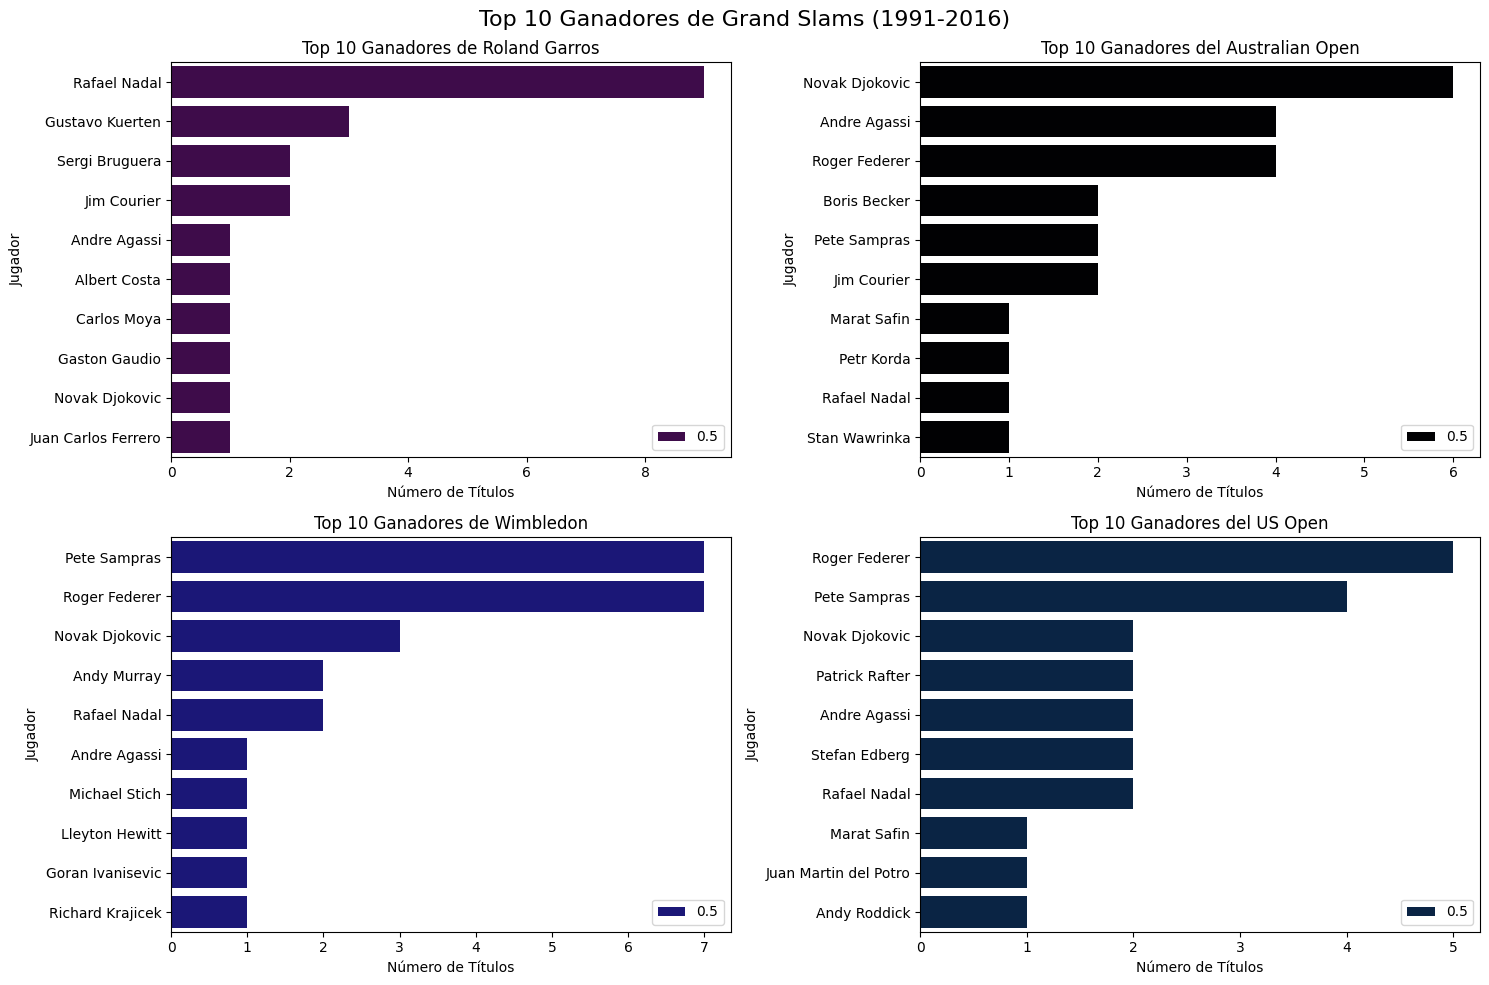

In [16]:
roland_garros = grand_slam_finals[grand_slam_finals['tourney_slug'] == 'roland-garros']
roland_garros_c = roland_garros.sort_values(by='year') 
roland_garros_c = roland_garros_c.groupby('winner_name').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

autralian_open = grand_slam_finals[grand_slam_finals['tourney_slug'] == 'australian-open']
autralian_open_c = autralian_open.sort_values(by='year')
autralian_open_c = autralian_open_c.groupby('winner_name').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

wimbledon= grand_slam_finals[grand_slam_finals['tourney_slug'] == 'wimbledon']
wimbledon_c = wimbledon.sort_values(by='year')
wimbledon_c = wimbledon_c.groupby('winner_name').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

us_open= grand_slam_finals[grand_slam_finals['tourney_slug'] == 'us-open']
us_open_c = us_open.sort_values(by='year') 
us_open_c = us_open_c.groupby('winner_name').size().reset_index(name='counts').sort_values(by='counts', ascending=False)


fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Top 10 Ganadores de Grand Slams (1991-2016)', fontsize=16)
sns.barplot(data=roland_garros_c.head(10), x='counts', y='winner_name', ax=ax[0, 0], palette='viridis' , hue=0.5)
ax[0, 0].set_title('Top 10 Ganadores de Roland Garros')
ax[0, 0].set_xlabel('Número de Títulos')
ax[0, 0].set_ylabel('Jugador')  

sns.barplot(data=autralian_open_c.head(10), x='counts', y='winner_name', ax=ax[0, 1], palette='magma', hue=0.5)
ax[0, 1].set_title('Top 10 Ganadores del Australian Open')
ax[0, 1].set_xlabel('Número de Títulos')
ax[0, 1].set_ylabel('Jugador')  

sns.barplot(data=wimbledon_c.head(10), x='counts', y='winner_name', ax=ax[1, 0], palette='plasma', hue=0.5)
ax[1, 0].set_title('Top 10 Ganadores de Wimbledon')
ax[1, 0].set_xlabel('Número de Títulos')
ax[1, 0].set_ylabel('Jugador')  

sns.barplot(data=us_open_c.head(10), x='counts', y='winner_name', ax=ax[1, 1], palette='cividis', hue=0.5)
ax[1, 1].set_title('Top 10 Ganadores del US Open')
ax[1, 1].set_xlabel('Número de Títulos')
ax[1, 1].set_ylabel('Jugador')  
plt.tight_layout()
plt.show()


## Barras

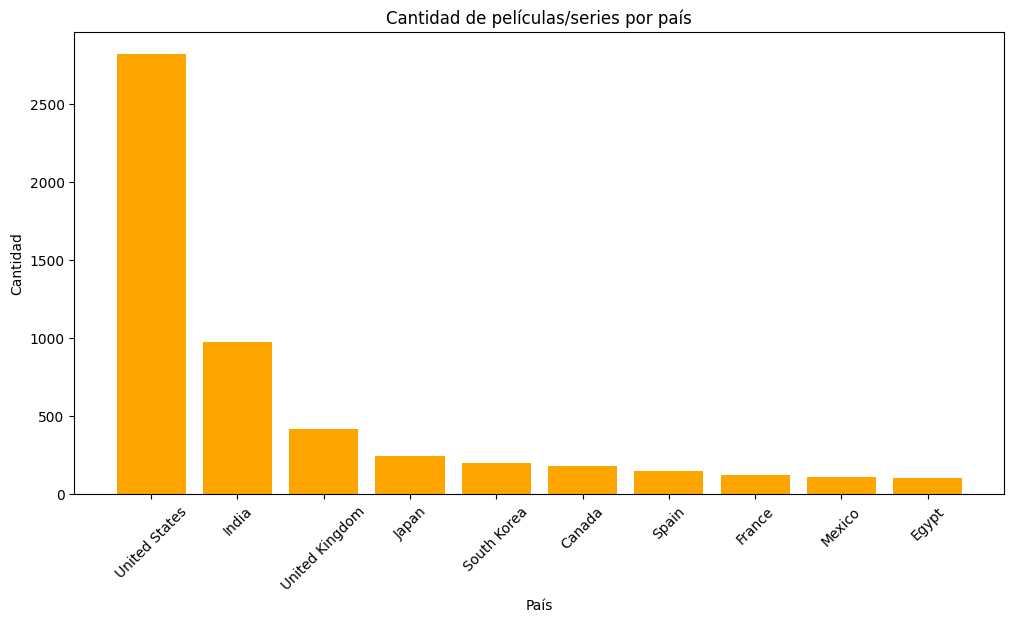

In [17]:
paises = df_1['country'].value_counts()

# ploteamos los primeros 10
plt.figure(figsize=(12, 6))
plt.bar(paises[:10].index, paises[:10].values, color = "orange")
plt.title('Cantidad de películas/series por país')
plt.xlabel('País')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

## GeoPandas

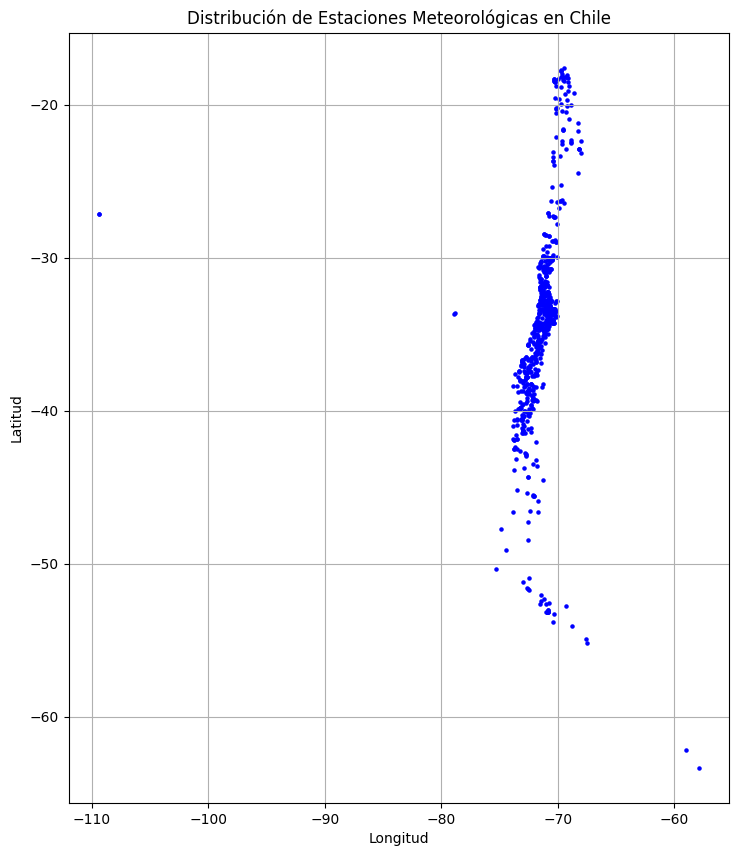

In [18]:
gdf = gpd.GeoDataFrame(data_inicial, geometry=gpd.points_from_xy(data_inicial['features.properties.longitud'], data_inicial['features.properties.latitud']))
gdf.set_crs(epsg=4326, inplace=True)
gdf.plot(figsize=(10, 10), color='blue', markersize=5)
plt.title('Distribución de Estaciones Meteorológicas en Chile')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

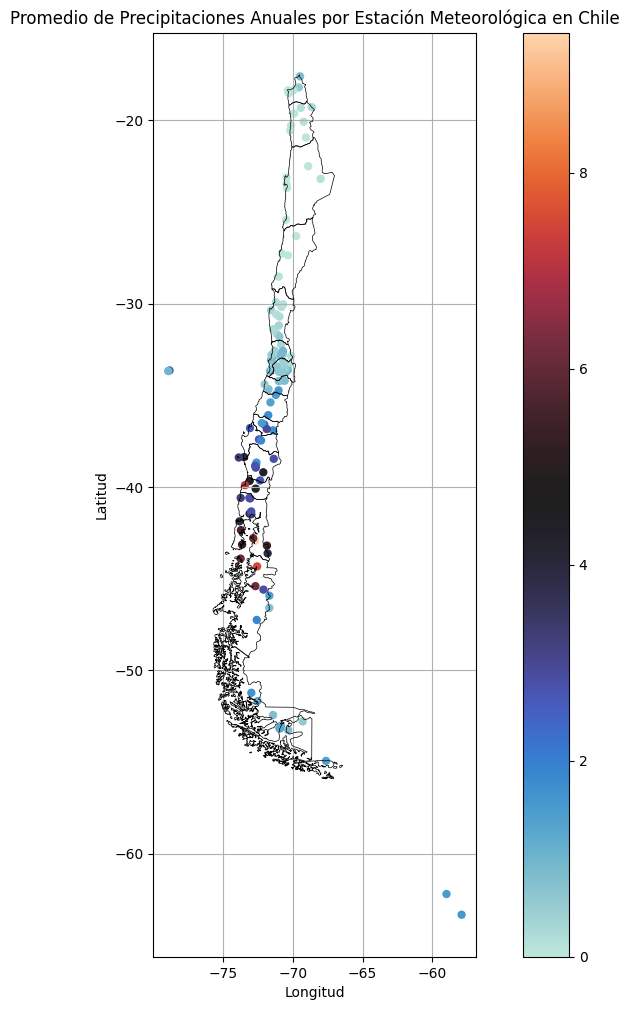

In [19]:
shapefile_path = "src/cl_shp/cl.shp"
chile = gpd.read_file(shapefile_path)
chile = chile.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12, 12))
chile.boundary.plot(ax=ax, color='black', linewidth=0.5)
gdf_promedios.plot(column='PromedioPrecipitacion', ax=ax, legend=True, cmap='icefire', markersize=25, alpha=1)
plt.title('Promedio de Precipitaciones Anuales por Estación Meteorológica en Chile')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

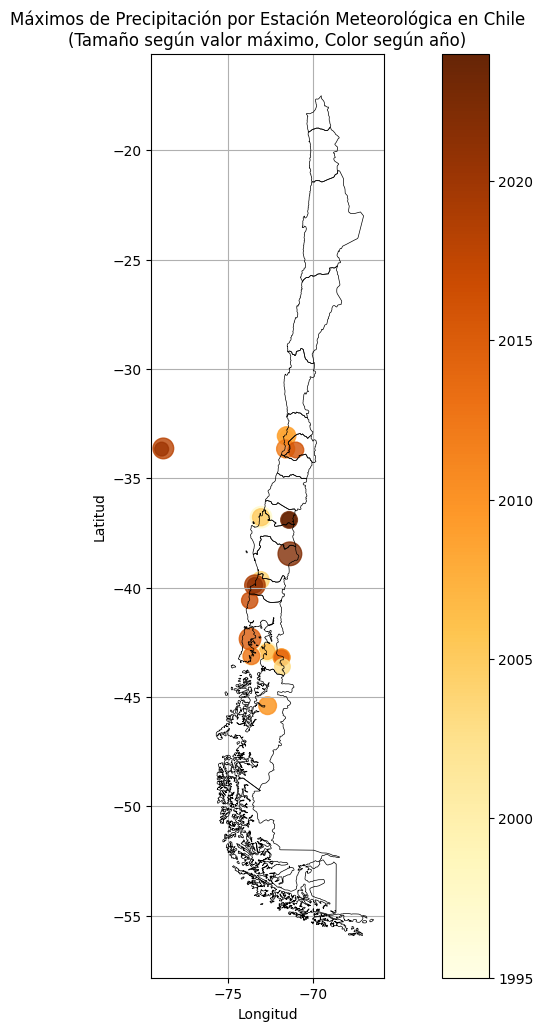

In [20]:
shapefile_path = "src/cl_shp/cl.shp"
chile = gpd.read_file(shapefile_path)
chile = chile.to_crs(epsg=4326)

#agregamos las coordernadas 

gdf_max_pre = gdf.merge(max_total, on = "features.properties.nombreEstacion")

fig, ax = plt.subplots(figsize=(15, 12))
chile.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Plotear puntos con tamaño variable y color por año

gdf_max_pre.plot(column='año', 
                ax=ax, 
                legend=True, 
                cmap='YlOrBr',  # o otro colormap para años
                markersize=max_total['max_año'],  # Ajusta el divisor según tus valores
                alpha=0.8)

plt.title('Máximos de Precipitación por Estación Meteorológica en Chile\n(Tamaño según valor máximo, Color según año)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

Text(0.5, 1.0, 'LLuvias por region')

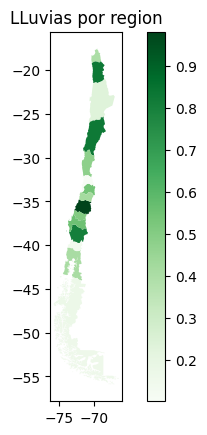

In [21]:
chile['promedio_X'] = np.random.rand(len(chile)) # creamos datos aleatorios para la muestra
chile.plot(cmap="Greens", column= 'promedio_X', legend=True)
plt.title('LLuvias por region')

NameError: name 'locales' is not defined

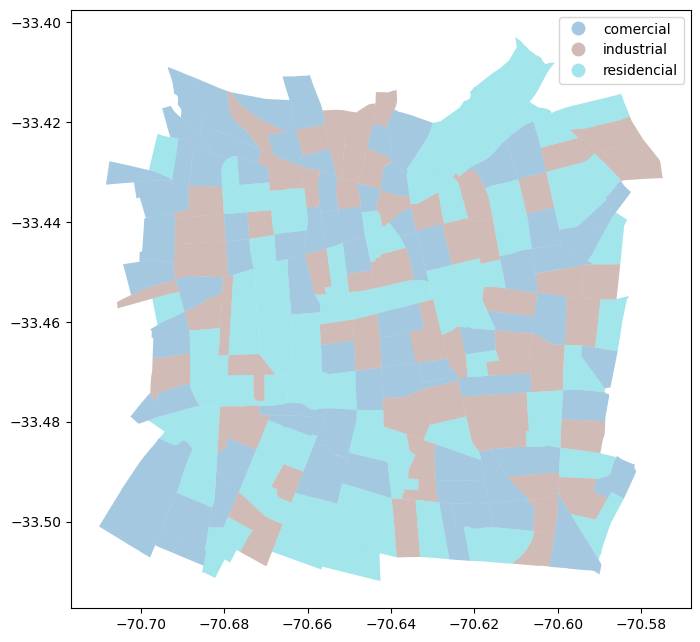

In [22]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

zonas.plot(ax=ax, figsize=(10,10), column='Tipo_zona', categorical=True, alpha=0.4, legend=True)
locales.plot(ax=ax, marker='o', color='k')

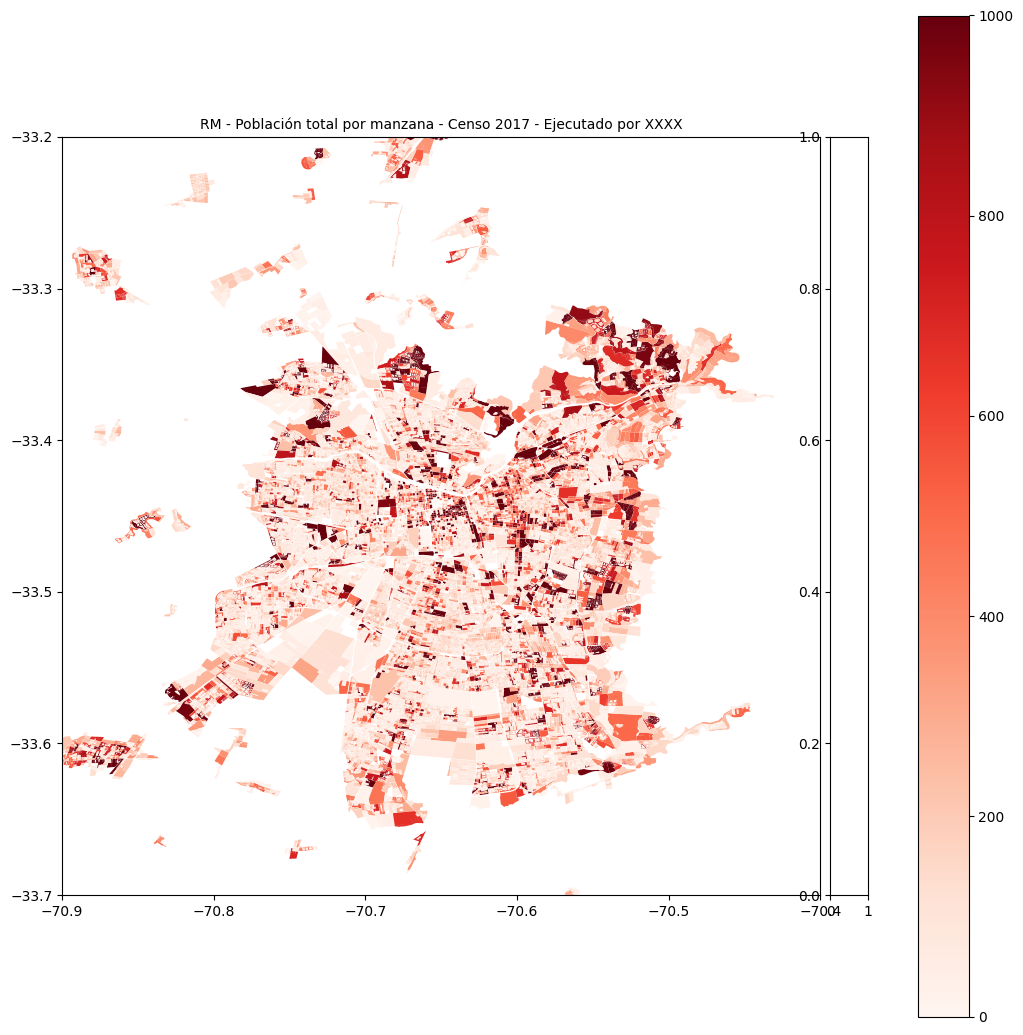

In [23]:
#Crear figura y ejes
fig=plt.figure(figsize=(13,13))
ax=fig.add_subplot(111)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

# cantidad de personas por manzana
Z=manz['TOTAL_PERS']
manz.plot(ax=ax, column='TOTAL_PERS', cmap='Reds', legend=True, vmin=0, vmax=1000)

com_projected = com.to_crs(epsg=3857)
com_projected.boundary.plot(ax=ax, lw=0.2, color='k')

xlim=[-70.9,-70.4]
ylim=[-33.7,-33.2]
for x, y, label in zip(com_projected.geometry.centroid.x, com_projected.geometry.centroid.y, com_projected.NOM_COMUNA):
    if xlim[0]<x<xlim[1] and ylim[0]<y<ylim[1]:
        ax.text(x, y, label, fontsize = 10)
        
ax.set_xlim(xlim)
ax.set_ylim(ylim)

## Reemplace 'XXX' por su apellido
ax.set_title('RM - Población total por manzana - Censo 2017 - Ejecutado por XXXX',fontsize=10)

## Reemplace 'XXX' por su apellido en el nombre del archivo de salida 
fig.savefig('PoblacionRM_C2017_XXXX.jpg')

In [27]:
# Figura 3: Mapa mundial de ciudades más pobladas

fig = px.scatter_geo(data_frame=df_filtered, # Su dataframe
                    lat='lat', # Columna de latitud
                    lon='lon', # Columna de longitud
                    color='eu_aqi', # Columna que representa el color de los puntos
                    hover_name='City', # Columna para el titulo del tooltip
                    projection="natural earth",
                    color_continuous_scale=px.colors.sequential.Inferno_r,
                    title="Calidad del aire de ciudades más pobladas", # Titulo del grafico
                    hover_data={
                        # Qué columnas mostrar en el tooltip
                        "Country": True,
                        "eu_aqi": True,
                        # Puede agregar otras...
                    },
                )

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0}, # Márgenes del gráfico
    height=600, # Altura del gráfico
    width=800, # Ancho del gráfico
)
fig.update_traces(
    marker=dict(size=10), # Tamaño de los puntos
)
fig.show()

## Scatterplot

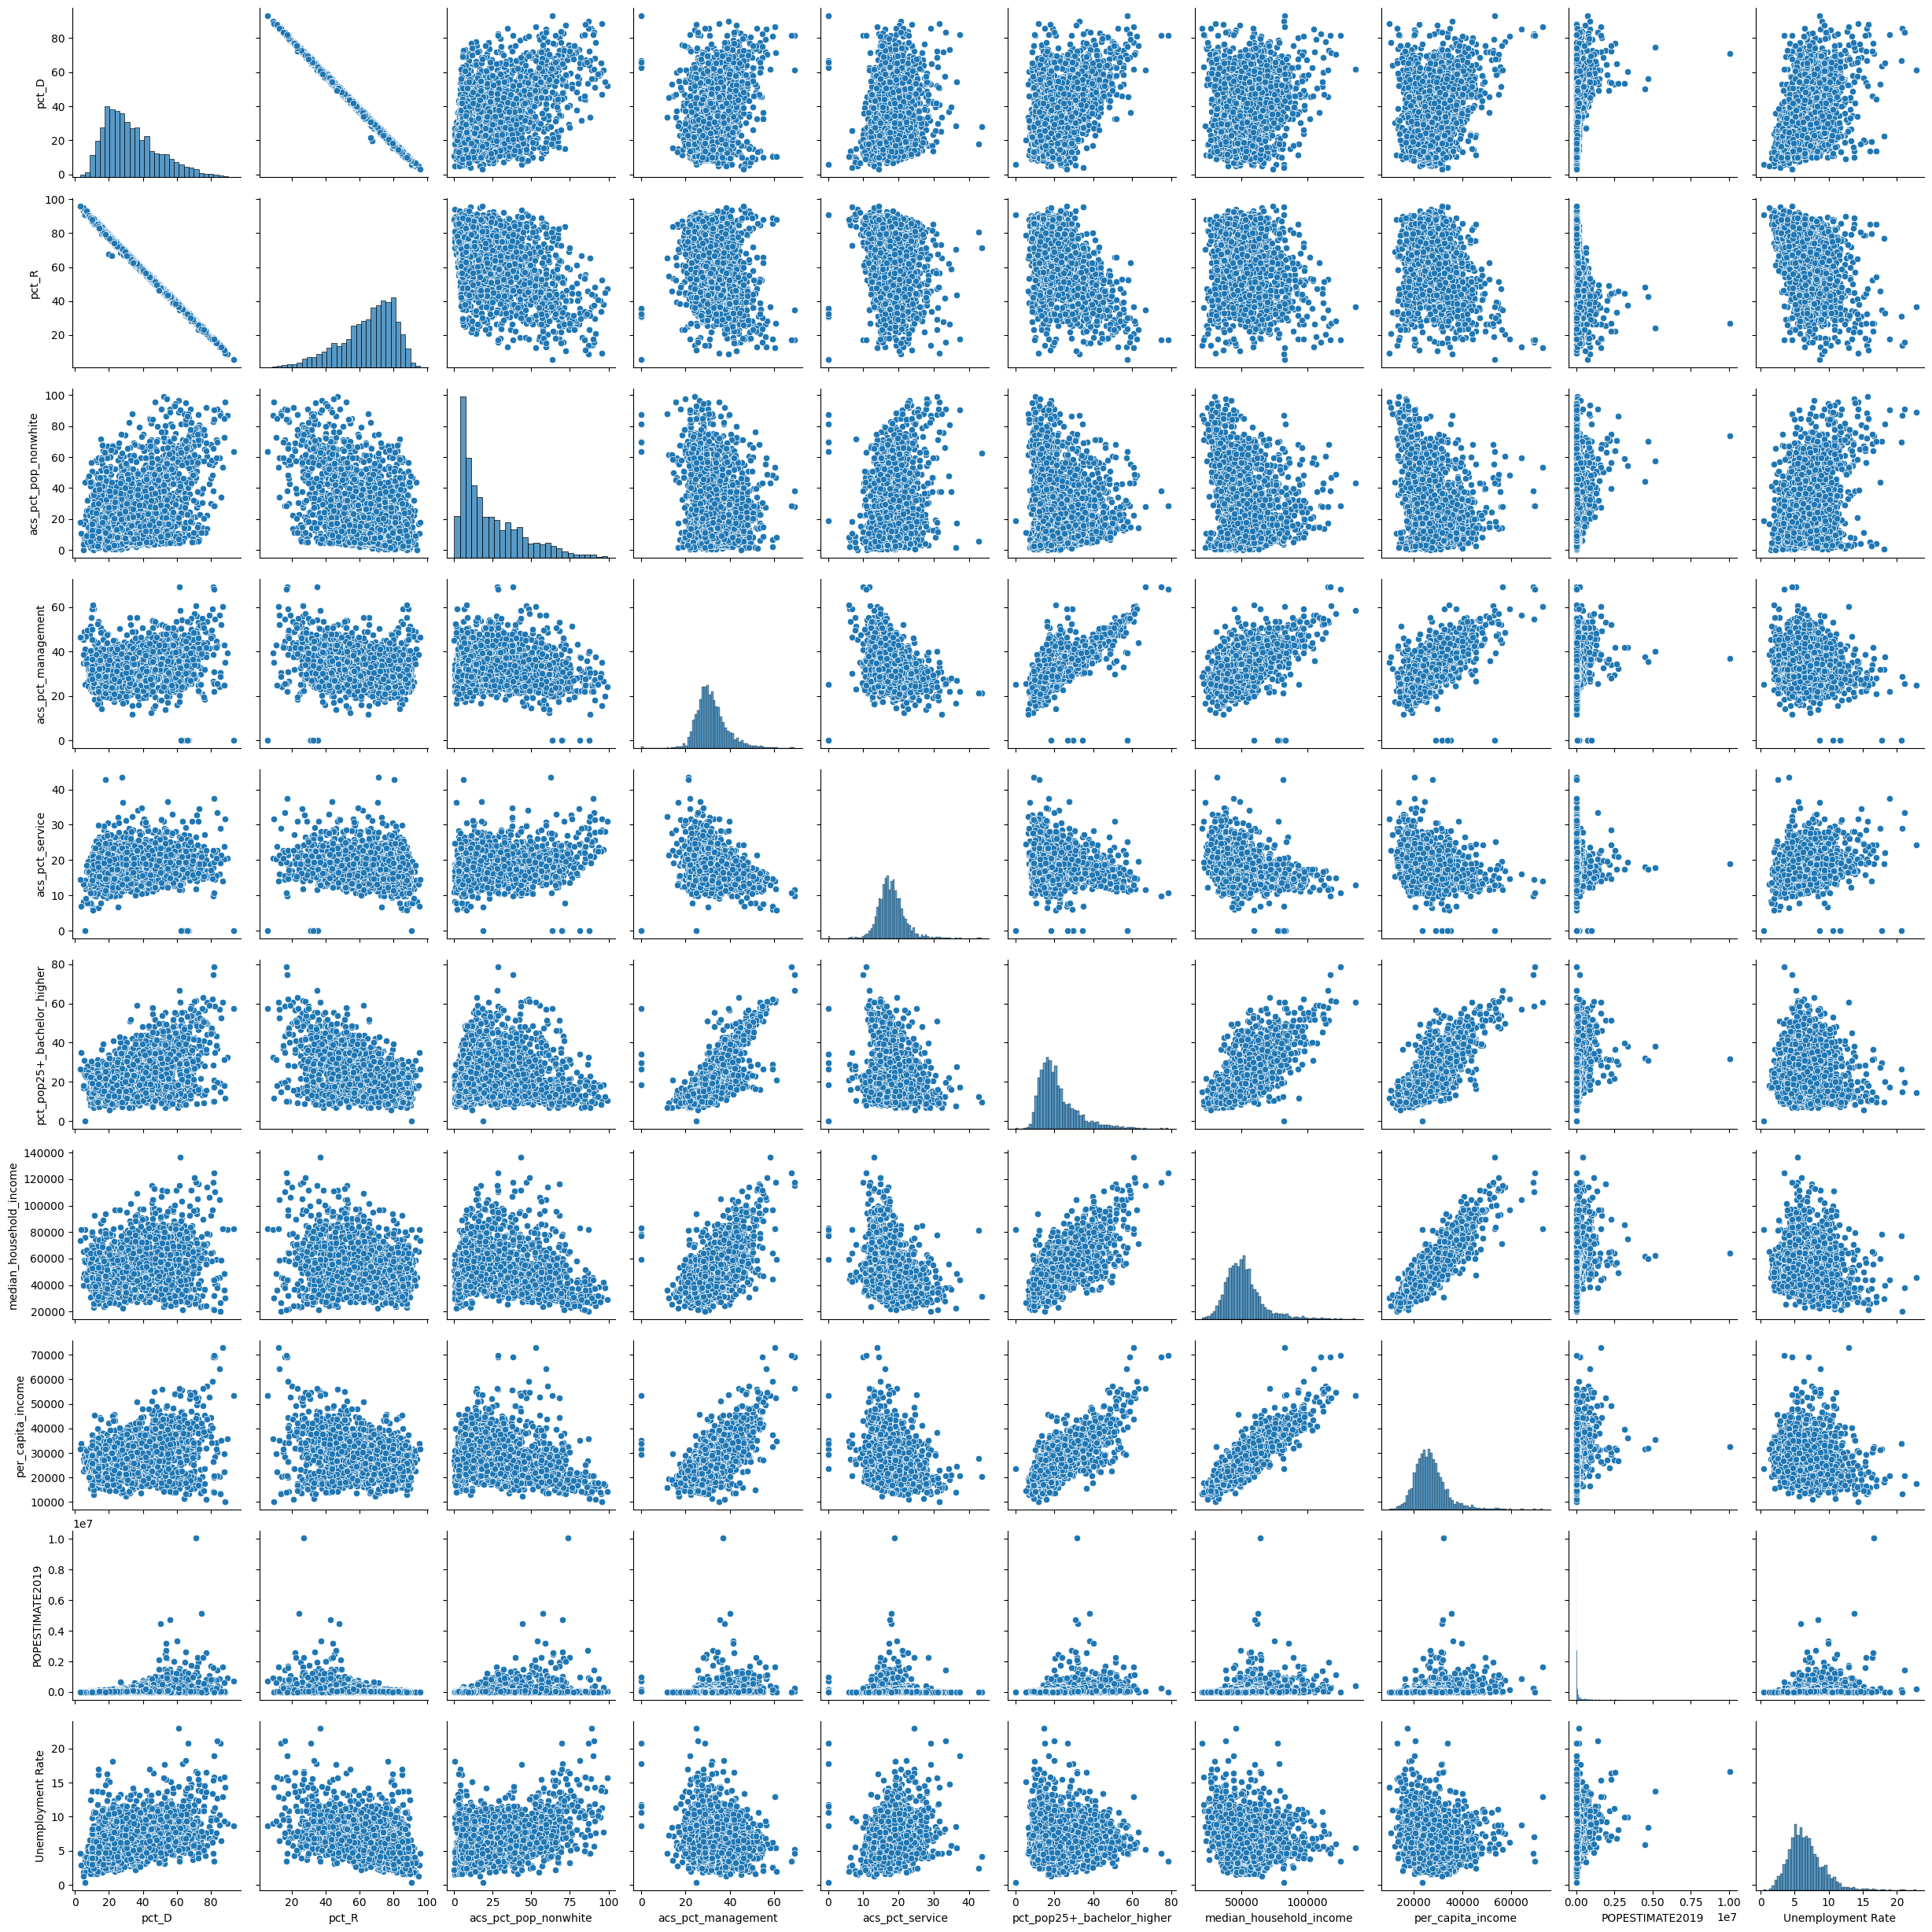

In [28]:
sns.pairplot(dat2)

Text(0, 0.5, 'edad')

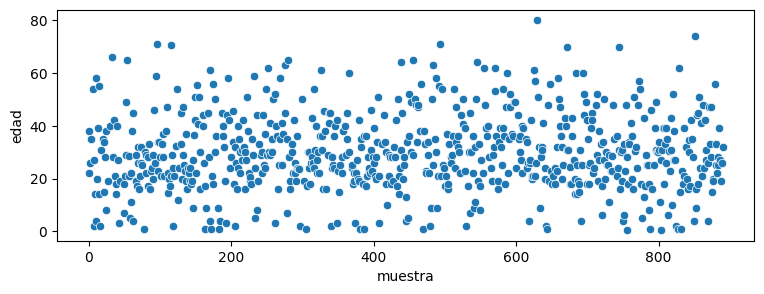

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax = sns.scatterplot(data.Age)
plt.xlabel('muestra')
plt.ylabel('edad')

<Axes: xlabel='Valores', ylabel='Valores2'>

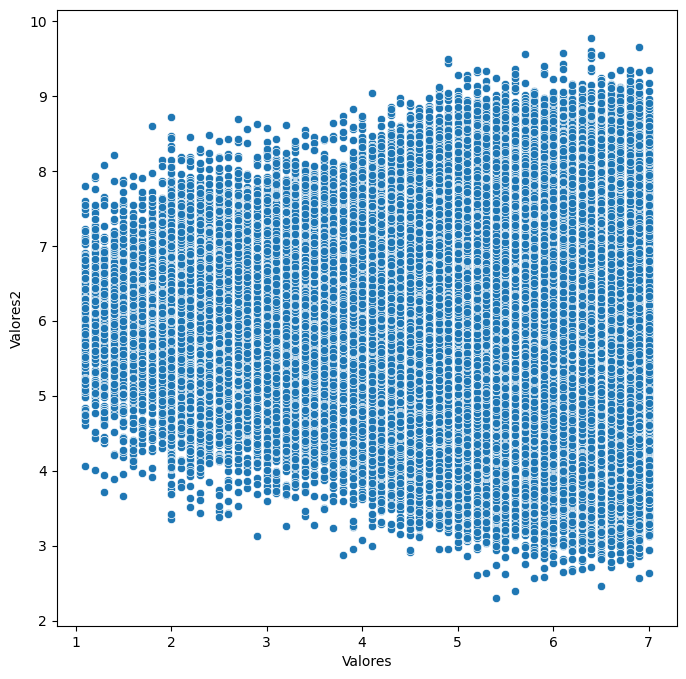

In [35]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

sns.scatterplot(data=dfe, x='Valores', y='Valores2', ax=ax)

<Axes: xlabel='Valores', ylabel='Valores2'>

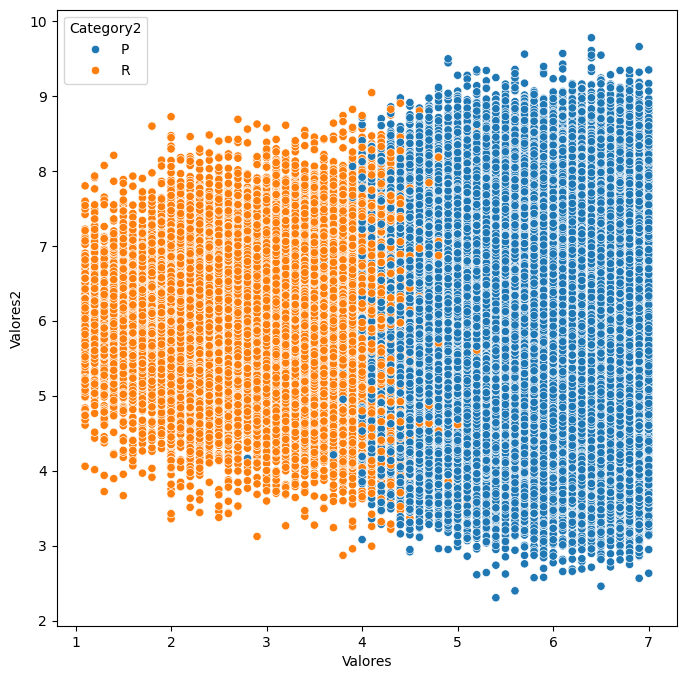

In [36]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

sns.scatterplot(data=dfe, x='Valores', y='Valores2', hue='Category2', ax=ax)

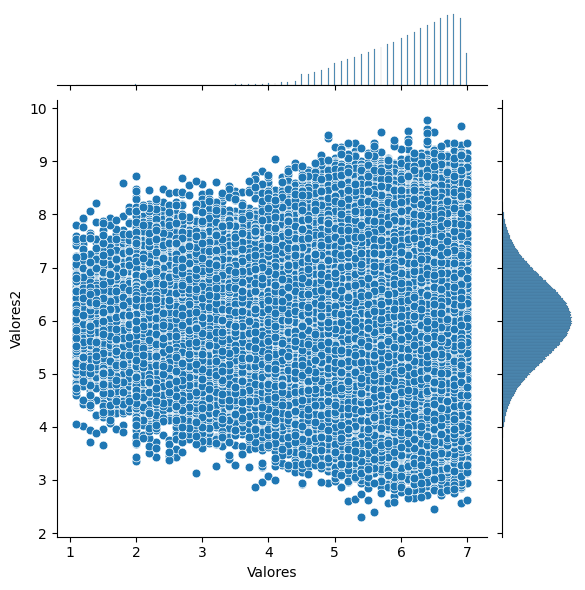

In [37]:
sns.jointplot(data=dfe, x='Valores', y='Valores2', s=40, kind='scatter', edgecolor='w')

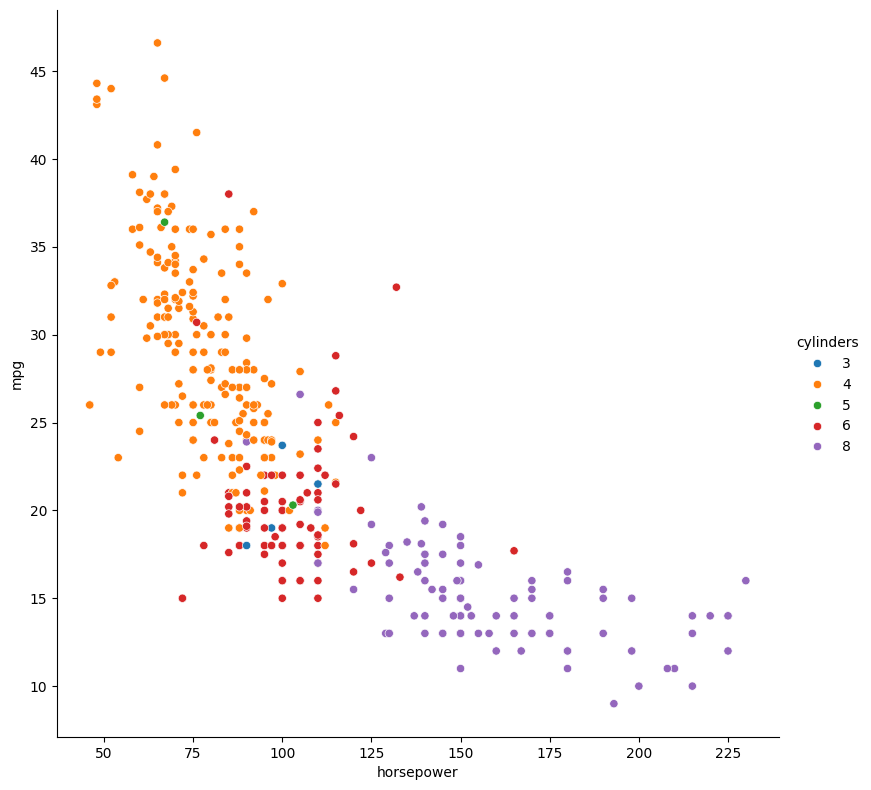

In [38]:
sns.pairplot(data=dfautos, y_vars='mpg', x_vars='horsepower', hue='cylinders', height=8)

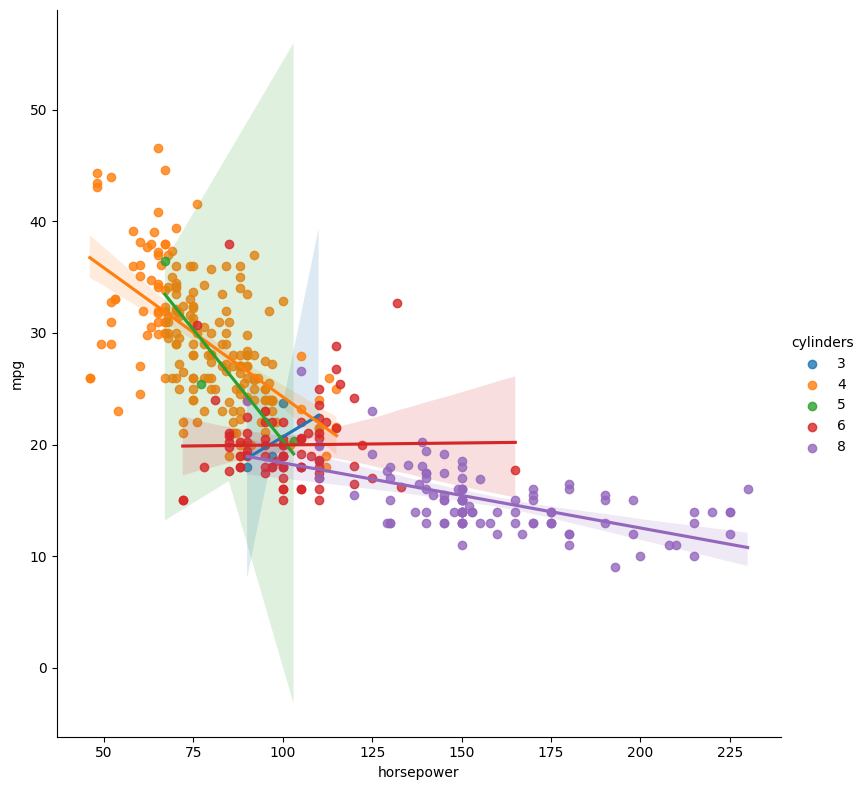

In [39]:
sns.lmplot(data=dfautos, y='mpg', x='horsepower', hue='cylinders', height=8)

## Histograma de barras

[(0.0, 90.0)]

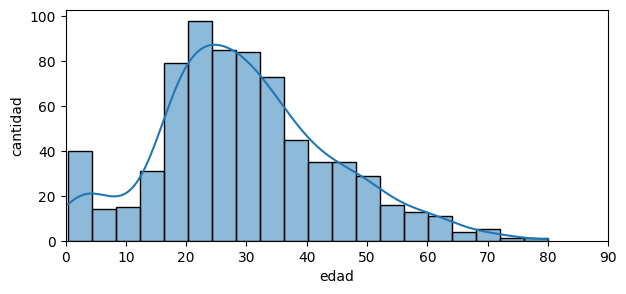

In [ ]:
ax = sns.histplot(data=data, x='Age', bins=20, kde=True)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

<Axes: xlabel='pct_D', ylabel='Count'>

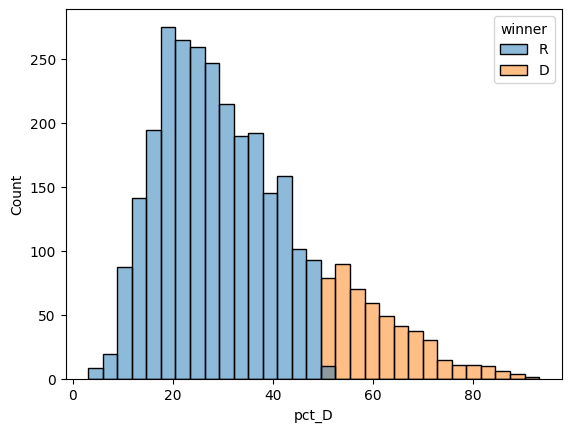

In [41]:
sns.histplot(data=dat2, x='pct_D', hue='winner')

## Solo KDE

Text(0, 0.5, 'KDE')

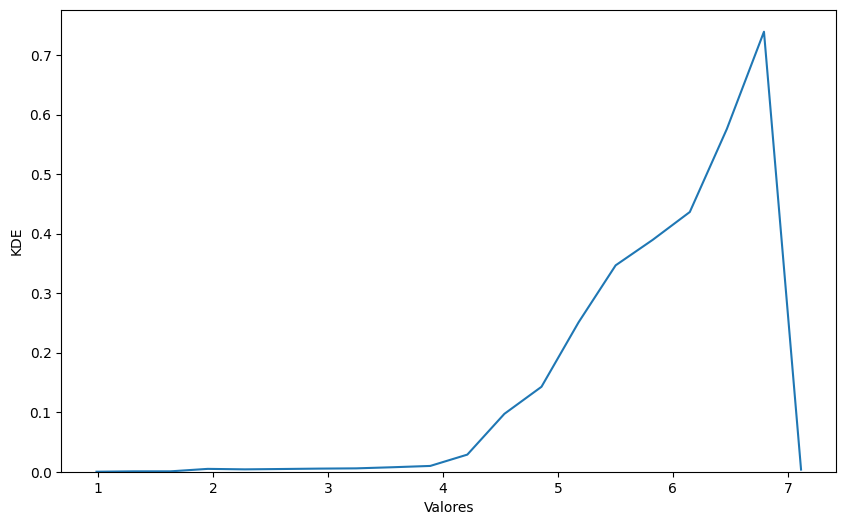

In [42]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

sns.kdeplot(data=dfe,x='Valores', ax=ax, gridsize=20);
ax.set_ylabel('KDE')

## Boxplot

### Simple

<Axes: ylabel='Valores'>

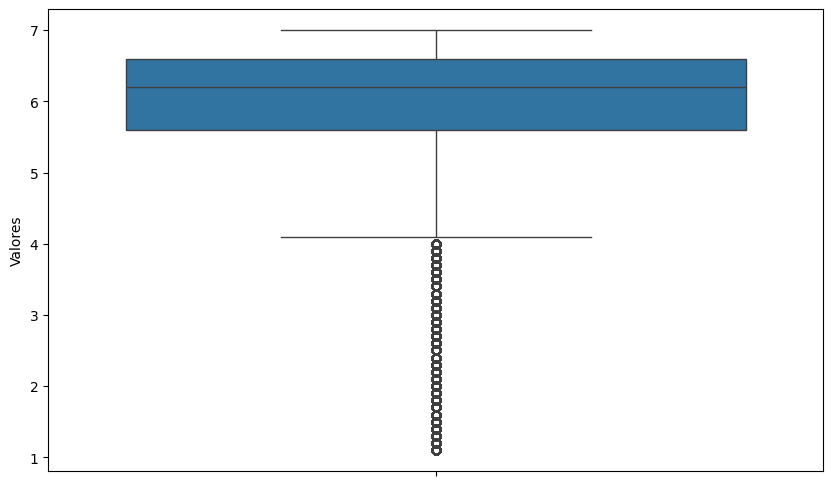

In [43]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

sns.boxplot(data=dfe,y='Valores',ax=ax)

### Con parametros en eje X

<Axes: xlabel='Category2', ylabel='Valores'>

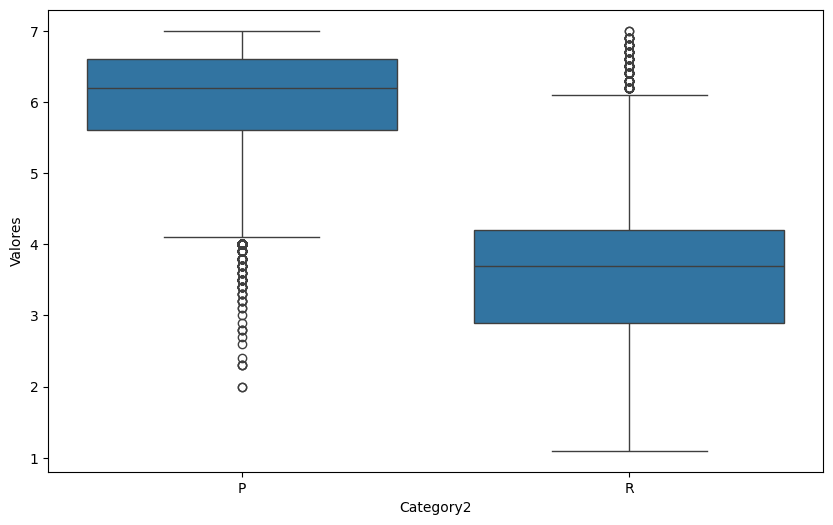

In [44]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

sns.boxplot(data=dfe, x='Category2', y='Valores',ax=ax)

<Axes: xlabel='winner', ylabel='acs_pct_pop_nonwhite'>

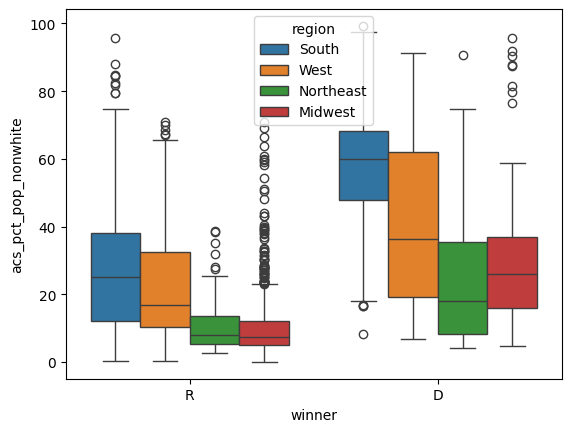

In [45]:
sns.boxplot(data=dat2, y='acs_pct_pop_nonwhite', x='winner', hue='region')

### Parametros eje X y distribucion

<Axes: xlabel='Category2', ylabel='Valores'>

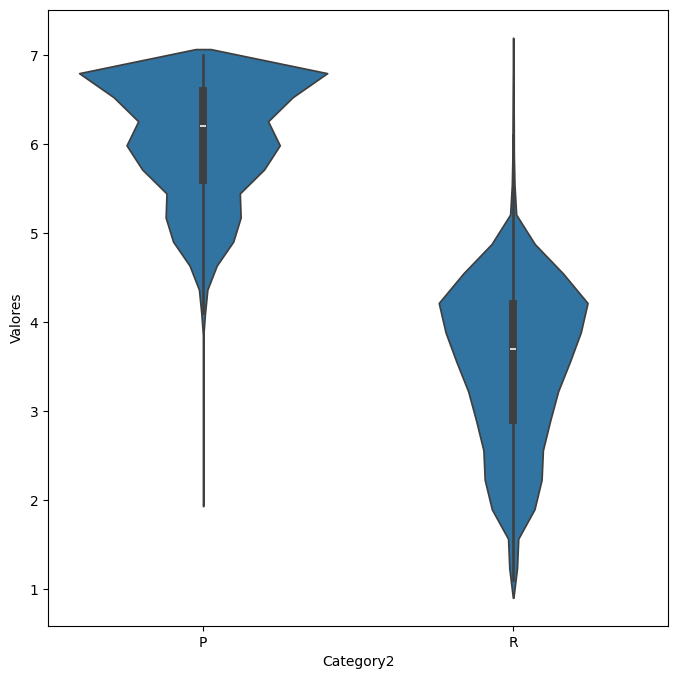

In [46]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

sns.violinplot(data=dfe, x='Category2', y='Valores', ax=ax, gridsize=20)

## Mapa de calor (correlacion)

<Axes: >

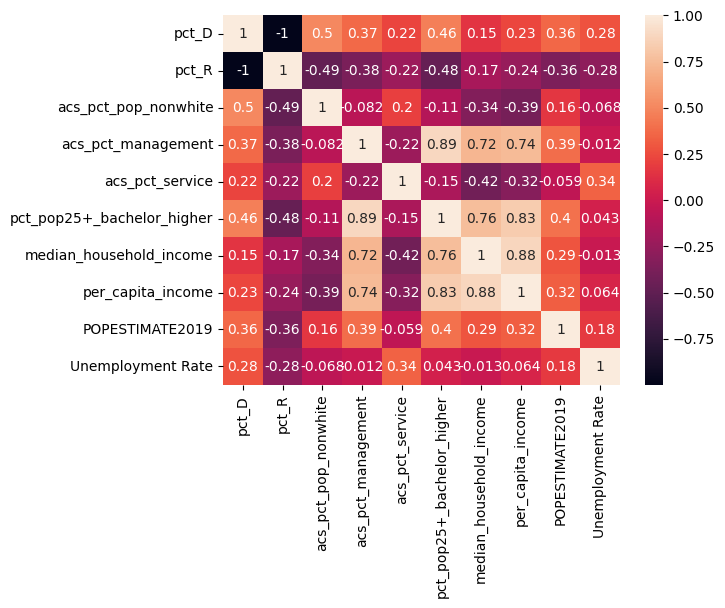

In [47]:
sns.heatmap(corr, annot=True)

# Calculos estadisticos

In [ ]:
data_select.describe()

data_select[['x', 'y']].mean()

data_select[['x', 'y']].median()

data_select[['x', 'y']].var()

data_select[['x', 'y']].std()

data_select[['x', 'y']].quantile(0.25)

np.percentile(dat['Unemployment Rate'],10)

corr = data_select['x'].corr(data_select['y'])


# Modelos

## Split Train/Test + Baseline (estadisticas)

In [48]:
RANDOM_STATE = 42
train, test = train_test_split(dfc, test_size=0.2, random_state=RANDOM_STATE)

y_train = np.array(train.mpg)
y_test = np.array(test.mpg)

y_base = np.full_like(y_test, y_train.mean(), dtype=float)
baseline = {"MSE": mean_squared_error(y_test, y_base),
            "MAE": mean_absolute_error(y_test, y_base),
            "R2": r2_score(y_test, y_base)}
baseline

{'MSE': 51.62029239680701,
 'MAE': 5.880956039956324,
 'R2': -0.011357808240890499}

## Regresión Lineal

np.float64(0.6059482578894348)

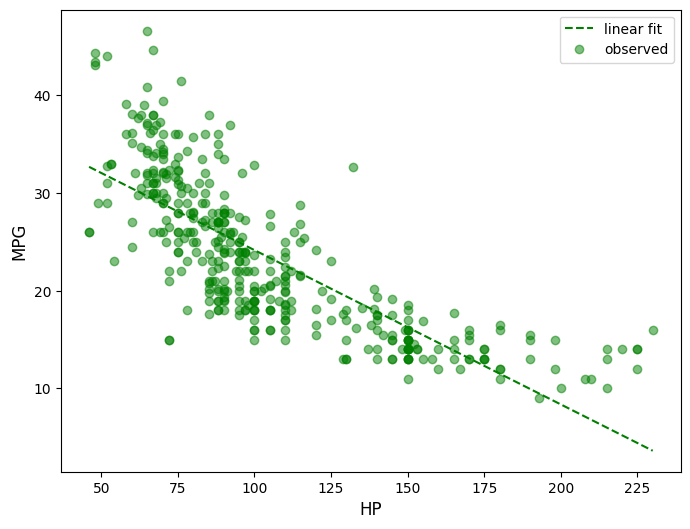

In [49]:
x = np.array(dfautos.horsepower)
y = np.array(dfautos.mpg)

X = sm.add_constant(x)

# modelo OLS (ordinary least squares) entrenado con los datos
regr_sm = sm.OLS(y, X)

# aplicar fit para entrenar y guardar el modelo
results_sm = regr_sm.fit()

# entregar informacion general del modelo
results_sm.summary()

# cpeficientes beta
beta0 = results_sm.params[0]
beta1 = results_sm.params[1]

fig, ax = plt.subplots(1,1, figsize=(8,6))

grid = np.linspace(np.min(dfautos.horsepower), np.max(dfautos.horsepower), 100)

y_fit = beta0 + beta1*grid

ax.plot(grid, y_fit, '--', color='g', label='linear fit')
ax.plot(dfautos.horsepower, dfautos.mpg, 'o', color='g', alpha=0.5, label='observed') 
ax.set_xlabel("HP", fontsize=12)
ax.set_ylabel("MPG", fontsize=12)
ax.legend()

results_sm.rsquared

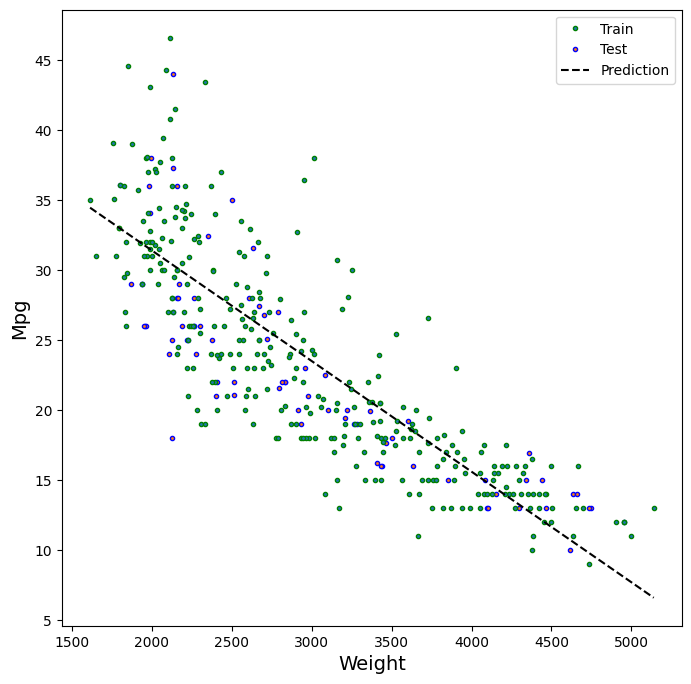

In [50]:
## Otra forma

num_feats = ["cylinders","displacement","horsepower","weight","acceleration","model year","origin"]
corrs = train[num_feats + ["mpg"]].corr(numeric_only=True)["mpg"].drop("mpg").abs().sort_values(ascending=False)
best_feat = corrs.index[0]
corrs, best_feat


# haremos los modelos usando la librearía sklearn en este caso.
# los inputs deben ser arreglos de numpy (en el caso del vector y podría ser Series, que es un arreglo de numpy + etiqueta)
y_train = np.array(train.mpg)
y_test = np.array(test.mpg)

#sklearn requiere que X sea una matrix de (n_samples x n_variables)
X_train = np.array(train.weight)
X_train = X_train.reshape(X_train.shape[0], 1) # reshape para que sea una matriz (n_samples x 1)

X_test = np.array(test.weight)
X_test = X_test.reshape(X_test.shape[0], 1) # reshape para que sea una matriz (n_samples x 1)

lin = LinearRegression().fit(X_train, y_train) # Fit para que aprenda los coeficientes
y_pred_train = lin.predict(X_test) # predecimos en test
metrics_lin_simple = {"MSE": mean_squared_error(y_test, y_pred_train),
                      "MAE": mean_absolute_error(y_test, y_pred_train),
                      "R2": r2_score(y_test, y_pred_train)}
metrics_lin_simple


fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

ax.plot(train.weight, train.mpg, '.', zorder=1, mec='green', label='Train') 
ax.plot(test.weight, test.mpg, '.', zorder=0, mec='blue', label='Test') 

xgrid = np.linspace(np.min(train.weight), np.max(train.weight), 100)
ax.plot(xgrid, lin.predict(xgrid.reshape(100, 1)),label='Prediction',color='k',ls='--')
ax.set_xlabel('Weight',fontsize=14)
ax.set_ylabel('Mpg',fontsize=14)
ax.legend()

## Regresión Polinomial

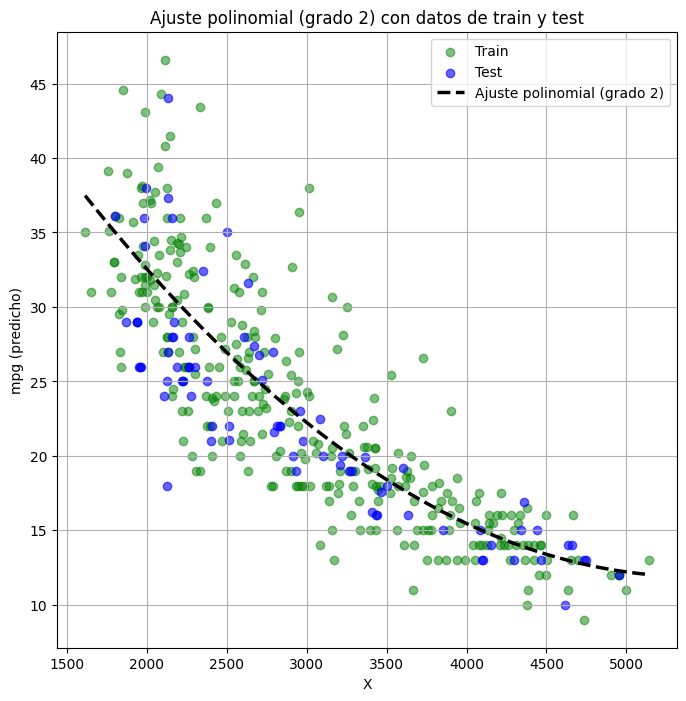

In [52]:
# Otra forma

poly = PolynomialFeatures(degree = 2, include_bias=False) #Haremos un ajuste polinomial de grado 2.

poly_x_train = poly.fit_transform(X_train) # Transformamos X_train a sus características polinomiales
poly_x_test = poly.fit_transform(X_test) # Transformamos X_test a sus características polinomiales

plr = LinearRegression()

plr.fit(poly_x_train, y_train)

y_pred_poly = plr.predict(poly_x_test)
metrics_poly = {"MSE": mean_squared_error(y_test, y_pred_poly),
                "MAE": mean_absolute_error(y_test, y_pred_poly),
                "R2": r2_score(y_test, y_pred_poly)}
metrics_poly


# Gráfico
plt.figure(figsize=(8,8))

# 1. Puntos reales
plt.scatter(X_train, y_train, color='g', alpha=0.5, label='Train')
plt.scatter(X_test, y_test, color='b', alpha=0.6, label='Test')

# 2. Curva ajustada (ordenada)
x_grid = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1,1)
y_grid = plr.predict(poly.transform(x_grid))
plt.plot(x_grid, y_grid, color='black', linewidth=2.5, label='Ajuste polinomial (grado 2)', ls = "--")

# 3. Detalles
plt.xlabel(X_train.columns[0] if hasattr(X_train, "columns") else "X")
plt.ylabel("mpg (predicho)")
plt.title("Ajuste polinomial (grado 2) con datos de train y test")
plt.legend()
plt.grid(True)
plt.show()

## Lineal Multivariable

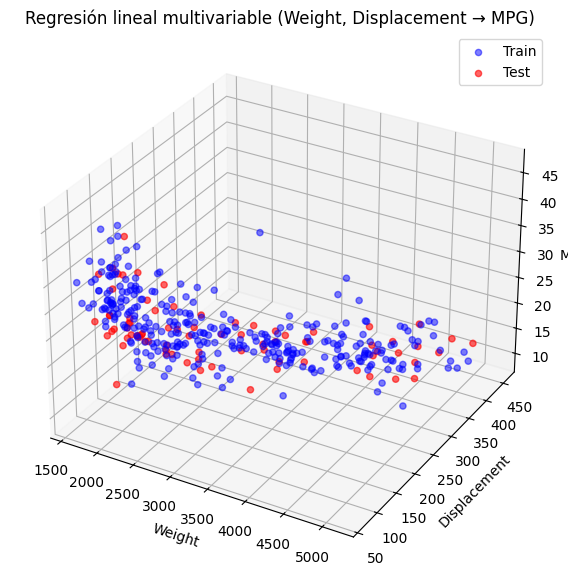

{'MSE': 18.30762724500912, 'MAE': 3.492736798949203, 'R2': 0.6413123423967872}


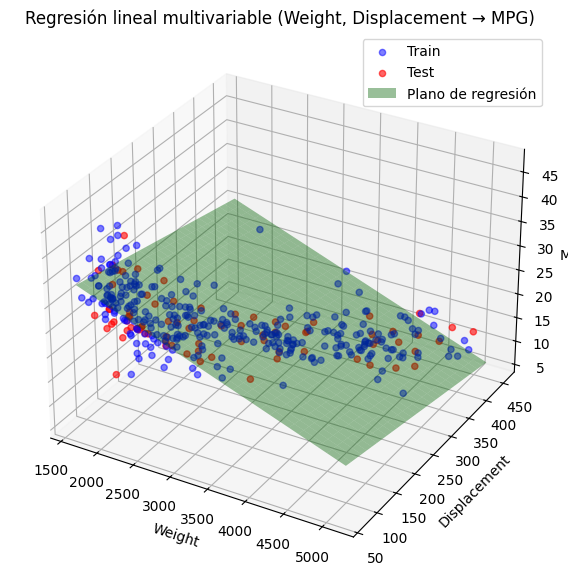

In [53]:
# --- GRAFICAR ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(train["weight"], train["displacement"], y_train, color='blue', alpha=0.5, label='Train')
ax.scatter(test["weight"], test["displacement"], y_test, color='red', alpha=0.6, label='Test')

# Malla para el plano de regresión
# Sirve para establecer los limites del plano
w_range = np.linspace(train["weight"].min(), train["weight"].max(), 30)
d_range = np.linspace(train["displacement"].min(), train["displacement"].max(), 30)
W, D = np.meshgrid(w_range, d_range) # Crear una malla 2D

# Predicción del plano
X_grid = np.column_stack((W.ravel(), D.ravel()))

# Etiquetas y estética
ax.set_xlabel("Weight")
ax.set_ylabel("Displacement")
ax.set_zlabel("MPG")
ax.set_title("Regresión lineal multivariable (Weight, Displacement → MPG)")
ax.legend()
plt.show()


# Variables predictoras y dependiente
features_2d = ["weight", "displacement"]
XtrM = train[features_2d].to_numpy()
XteM = test[features_2d].to_numpy()

# Pipeline: estandarización + regresión lineal
lin_multi = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LinearRegression())
])

lin_multi.fit(XtrM, y_train)
y_pred_train = lin_multi.predict(XtrM)
y_pred_test = lin_multi.predict(XteM)

# Métricas
metrics_lin_multi = {
    "MSE": mean_squared_error(y_test, y_pred_test),
    "MAE": mean_absolute_error(y_test, y_pred_test),
    "R2":  r2_score(y_test, y_pred_test)
}
print(metrics_lin_multi)


# --- GRAFICAR ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(train["weight"], train["displacement"], y_train, color='blue', alpha=0.5, label='Train')
ax.scatter(test["weight"], test["displacement"], y_test, color='red', alpha=0.6, label='Test')

# Malla para el plano de regresión
w_range = np.linspace(train["weight"].min(), train["weight"].max(), 30)
d_range = np.linspace(train["displacement"].min(), train["displacement"].max(), 30)
W, D = np.meshgrid(w_range, d_range)

# Predicción del plano
X_grid = np.column_stack((W.ravel(), D.ravel()))
Y_pred = lin_multi.predict(X_grid).reshape(W.shape)

# Plano de regresión
ax.plot_surface(W, D, Y_pred, color='green', alpha=0.4, label='Plano de regresión')

# Etiquetas y estética
ax.set_xlabel("Weight")
ax.set_ylabel("Displacement")
ax.set_zlabel("MPG")
ax.set_title("Regresión lineal multivariable (Weight, Displacement → MPG)")
ax.legend()
plt.show()

## Ridge y Lasso (Multivariable con cambios en los coeficientes)

Ridge: {'MSE': 18.298932269906064, 'MAE': 3.4901587681708444, 'R2': 0.6414826965454103, 'best_alpha': 1.0}


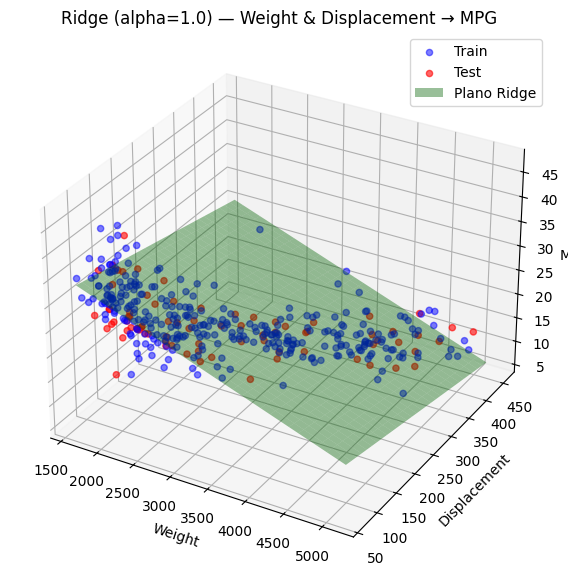

Lasso: {'MSE': 18.304709538673993, 'MAE': 3.4924054847103654, 'R2': 0.6413695068363356, 'best_alpha': 0.001}


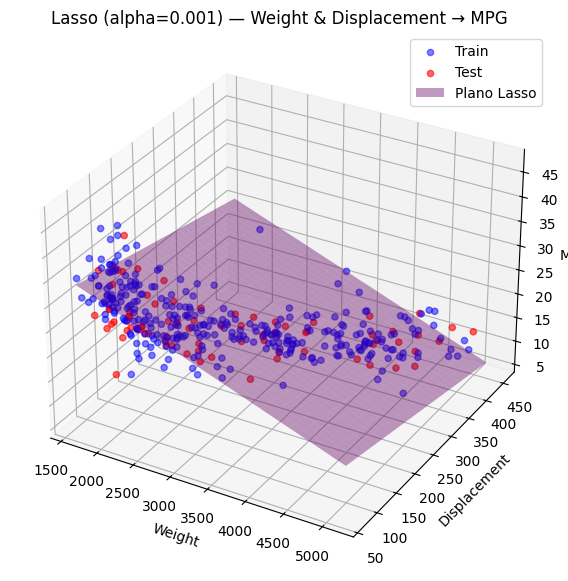

In [55]:
# --- Datos ---
XtrM = train[features_2d].to_numpy()
XteM = test[features_2d].to_numpy()

# --- Ridge con GridSearchCV ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
ridge = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("rg", Ridge(random_state=42))]),
    param_grid={"rg__alpha": [0.1, 1.0, 10.0]},
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=1
)

# Kfold sirve para validar el modelo durante el entrenamiento
# y evitar overfitting al buscar el mejor hiperparámetro (alpha en este caso

# GridSearchCV realiza validación cruzada para seleccionar el mejor alpha


ridge.fit(XtrM, y_train)

# Predicciones
y_pred_train_ridge = ridge.predict(XtrM)
y_pred_test_ridge  = ridge.predict(XteM)

# Métricas
metrics_ridge = {
    "MSE": mean_squared_error(y_test, y_pred_test_ridge),
    "MAE": mean_absolute_error(y_test, y_pred_test_ridge),
    "R2":  r2_score(y_test, y_pred_test_ridge),
    "best_alpha": ridge.best_params_["rg__alpha"],
}
print("Ridge:", metrics_ridge)

# --- GRAFICAR plano de regresión + puntos ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(train["weight"], train["displacement"], y_train, color='blue', alpha=0.5, label='Train')
ax.scatter(test["weight"],  test["displacement"],  y_test,  color='red',  alpha=0.6, label='Test')

# Malla del plano
w_range = np.linspace(train["weight"].min(), train["weight"].max(), 30)
d_range = np.linspace(train["displacement"].min(), train["displacement"].max(), 30)
W, D = np.meshgrid(w_range, d_range)
X_grid = np.column_stack((W.ravel(), D.ravel()))

# Predicción del plano con el pipeline (usa el scaler interno)
Y_pred = ridge.predict(X_grid).reshape(W.shape)

# Plano
ax.plot_surface(W, D, Y_pred, color='green', alpha=0.4, label='Plano Ridge')

ax.set_xlabel("Weight")
ax.set_ylabel("Displacement")
ax.set_zlabel("MPG")
ax.set_title(f"Ridge (alpha={metrics_ridge['best_alpha']}) — Weight & Displacement → MPG")
ax.legend()
plt.show()



# --- Datos ---
XtrM = train[features_2d].to_numpy()
XteM = test[features_2d].to_numpy()

# --- Lasso con GridSearchCV ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
lasso = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("ls", Lasso(random_state=42, max_iter=10000))]),
    param_grid={"ls__alpha": [0.001, 0.01, 0.1]},
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=1
)
lasso.fit(XtrM, y_train)

# Predicciones
y_pred_train_lasso = lasso.predict(XtrM)
y_pred_test_lasso  = lasso.predict(XteM)

# Métricas
metrics_lasso = {
    "MSE": mean_squared_error(y_test, y_pred_test_lasso),
    "MAE": mean_absolute_error(y_test, y_pred_test_lasso),
    "R2":  r2_score(y_test, y_pred_test_lasso),
    "best_alpha": lasso.best_params_["ls__alpha"],
}
print("Lasso:", metrics_lasso)

# --- GRAFICAR plano de regresión + puntos ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Puntos reales
ax.scatter(train["weight"], train["displacement"], y_train, color='blue', alpha=0.5, label='Train')
ax.scatter(test["weight"],  test["displacement"],  y_test,  color='red',  alpha=0.6, label='Test')

# Malla del plano
w_range = np.linspace(train["weight"].min(), train["weight"].max(), 30)
d_range = np.linspace(train["displacement"].min(), train["displacement"].max(), 30)
W, D = np.meshgrid(w_range, d_range)
X_grid = np.column_stack((W.ravel(), D.ravel()))

# Predicción del plano con el pipeline (usa el scaler interno)
Y_pred = lasso.predict(X_grid).reshape(W.shape)

# Plano
ax.plot_surface(W, D, Y_pred, color='purple', alpha=0.4, label='Plano Lasso')

ax.set_xlabel("Weight")
ax.set_ylabel("Displacement")
ax.set_zlabel("MPG")
ax.set_title(f"Lasso (alpha={metrics_lasso['best_alpha']}) — Weight & Displacement → MPG")
ax.legend()
plt.show()

## Regresión Logística

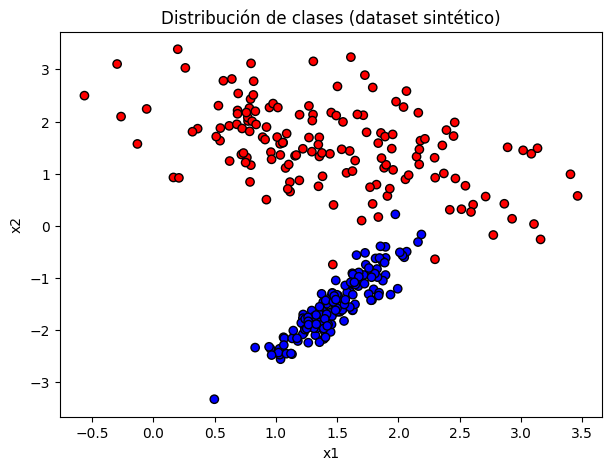

Accuracy: 0.989
Precision: 0.978
Recall: 1.000
F1-score: 0.989


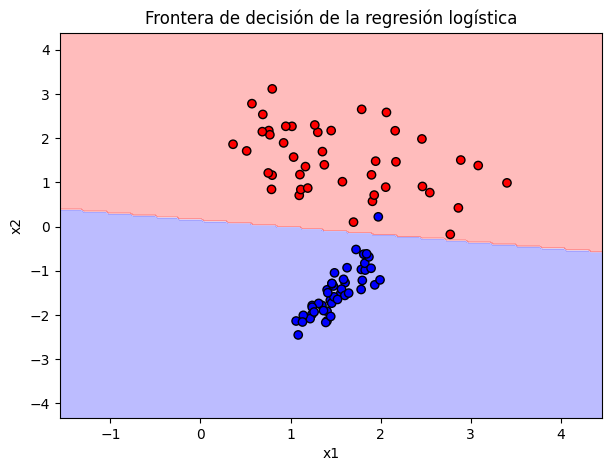

In [56]:
# Generar dataset sintético
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualizar los datos
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title('Distribución de clases (dataset sintético)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


# Entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluar desempeño
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}\nPrecision: {prec:.3f}\nRecall: {rec:.3f}\nF1-score: {f1:.3f}")


# Crear una malla de puntos para visualizar la frontera
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', edgecolor='k')
plt.title('Frontera de decisión de la regresión logística')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Regresión Multilineal

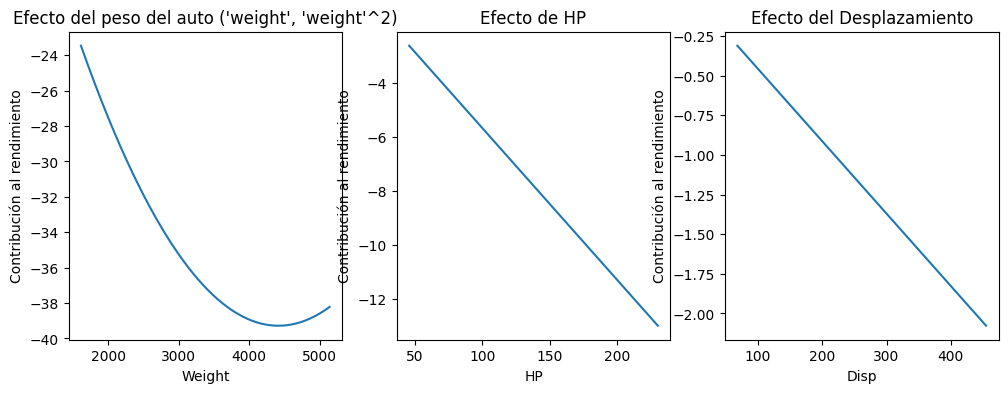

In [57]:
def build_xmatrix(df, columns, cols_squared=[]):
    x_matrix = df[columns].copy()
    
    for col in cols_squared:
        x_matrix['%s_2'%col] = df[col]**2
    
    x_matrix = sm.add_constant(x_matrix)
    return(x_matrix)


columns = ['displacement','horsepower','weight']
cols_squared = ['weight']

x_matrix = build_xmatrix(dfautos, columns, cols_squared)

y = dfautos.mpg
fitted_model = sm.OLS(y, x_matrix, hasconst=True).fit()
fitted_model.summary()

fig = plt.figure(figsize=(12,4))

x_wt = np.arange(dfautos['weight'].min(), dfautos['weight'].max(), 0.01)
wtcoef = fitted_model.params.weight
wt2coef = fitted_model.params.weight_2
y_wt = wtcoef*x_wt + wt2coef*x_wt**2

ax1 = fig.add_subplot(131)
ax1.plot(x_wt, y_wt)
ax1.set_title("Efecto del peso del auto ('weight', 'weight'^2)")
ax1.set_xlabel("Weight")
ax1.set_ylabel("Contribución al rendimiento")

hpcoef = fitted_model.params.horsepower
x_hp = np.arange(dfautos['horsepower'].min(), dfautos['horsepower'].max(), 0.01)
y_hp = hpcoef*x_hp

ax2 = fig.add_subplot(132)
ax2.plot(x_hp, y_hp)
ax2.set_title("Efecto de HP")
ax2.set_xlabel("HP")
ax2.set_ylabel("Contribución al rendimiento")

dispcoef = fitted_model.params.displacement
x_disp = np.arange(dfautos['displacement'].min(), dfautos['displacement'].max(), 0.01)
y_disp = dispcoef*x_disp

ax3=fig.add_subplot(133)
ax3.plot(x_disp, y_disp)
ax3.set_title("Efecto del Desplazamiento")
ax3.set_xlabel("Disp")
ax3.set_ylabel("Contribución al rendimiento")

plt.show()

## KNN

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        78
           1       0.87      0.93      0.90        42

    accuracy                           0.93       120
   macro avg       0.91      0.93      0.92       120
weighted avg       0.93      0.93      0.93       120



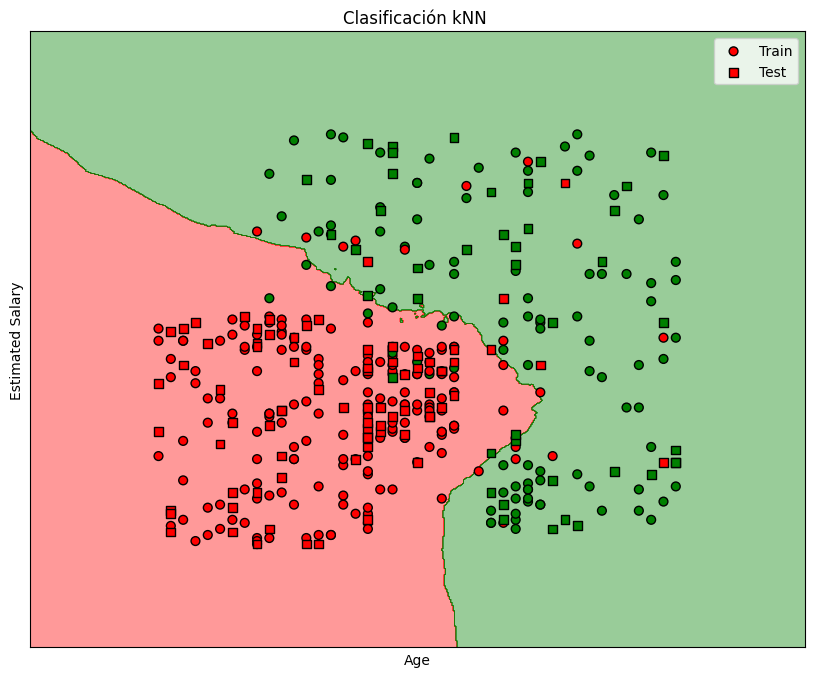

In [63]:
df = pd.read_csv('data\\Social_Network_Ads.csv')

# seleccionamos las variables predictoras y la variable dependiente
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

# normalización con StandardScaler
sc = StandardScaler()

X_sc = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size = 0.3, random_state = 5)

# definimos el modelo y especificamos sus hiperparámetros
classifier = KNeighborsClassifier(n_neighbors = 15)

# ajustamos a los datos de entrenamiento
classifier.fit(X_train, y_train)

#predecimos las categorías para el dataset de prueba
y_pred_test = classifier.predict(X_test)


#creamos una grilla con valores de X1 (Age) y X2 (EstimatedSalary)
X1, X2 = np.meshgrid(np.arange(X_train[:,0].min()-1, X_train[:,0].max()+1,0.01),
                     np.arange(X_train[:,1].min()-1,X_train[:,1].max()+1,0.01))


#predecimos la clase de salida para cada par de puntos (X1,X2) de la grilla
#X1, X2 son matrices con los valores en cada punto de la grilla. 
#X1.ravel() son las versiones "flattened". Para la predicción, transformamos X1, X2 en vectores
# luego con reshape volvemos a darle la forma de matrix (grilla) al vector de resultados
X_grid = np.array([X1.ravel(), X2.ravel()]).T
mesh_predict = classifier.predict(X_grid).reshape(X1.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
 
#grafico de contornos de mesh_predict, para visualizar la frontera entre las dos clases
im = ax.contourf(X1, X2, mesh_predict, alpha = 0.4, cmap = ListedColormap(('red', 'green')))
#plot de los datos de entrenamiento
ax.scatter(X_train[:,0], X_train[:,1], c=y_train, s=40, edgecolors='k', cmap=ListedColormap(('red', 'green')), label='Train')
ax.scatter(X_test[:,0], X_test[:,1], c=y_test, marker='s', s=40, edgecolors='k', cmap=ListedColormap(('red', 'green')), label='Test')
         
ax.set_title('Clasificación kNN ')
ax.set_xlabel('Age')
ax.set_ylabel('Estimated Salary')

xlabels = np.arange(10,70,10)
xticks = (xlabels-X_train[:,0].mean())/X_train[:,0].std()
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=14)

ylabels = np.arange(10000,180000,20000)
yticks = (ylabels-X_train[:,1].mean())/X_train[:,1].std()
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=14)

# limites de los ejes
ax.set_xlim(X1.min(), X1.max())
ax.set_ylim(X2.min(), X2.max())
ax.legend()



print(report0)

Confusion matrix: [[72  6]
 [ 3 39]]
Accuracy: 0.925
Recall: 0.9285714285714286
Precision: 0.8666666666666667
F score: 0.896551724137931


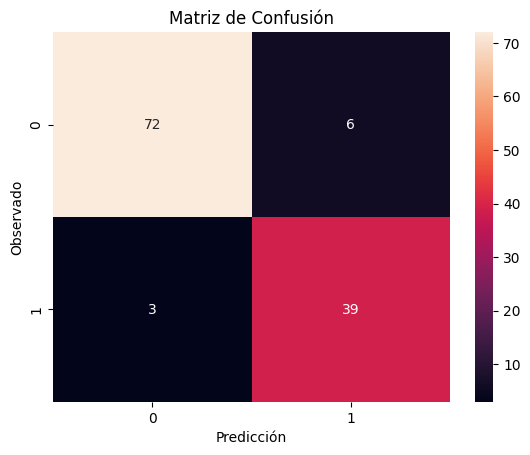

In [64]:
#matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred_test)

print('Confusion matrix:', cm)

#graficamos la matriz de confusión
sns.heatmap(cm, annot=True)
plt.ylabel('Observado')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')

accuracy=metrics.accuracy_score(y_test,y_pred_test)
print('Accuracy:',accuracy) 

recall=metrics.recall_score(y_test,y_pred_test)
print('Recall:',recall) 

precision=metrics.precision_score(y_test,y_pred_test)
print('Precision:',precision) 

fscore=metrics.f1_score(y_test,y_pred_test)
print('F score:',fscore)

#también podemos imprimir un resumen de las métricas de clasificación
report0 = metrics.classification_report(y_test,y_pred_test)

## Árboles

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names

C:\Users\crist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



Text(0.5, 1.0, 'Clasificación Decision Trees - Female')

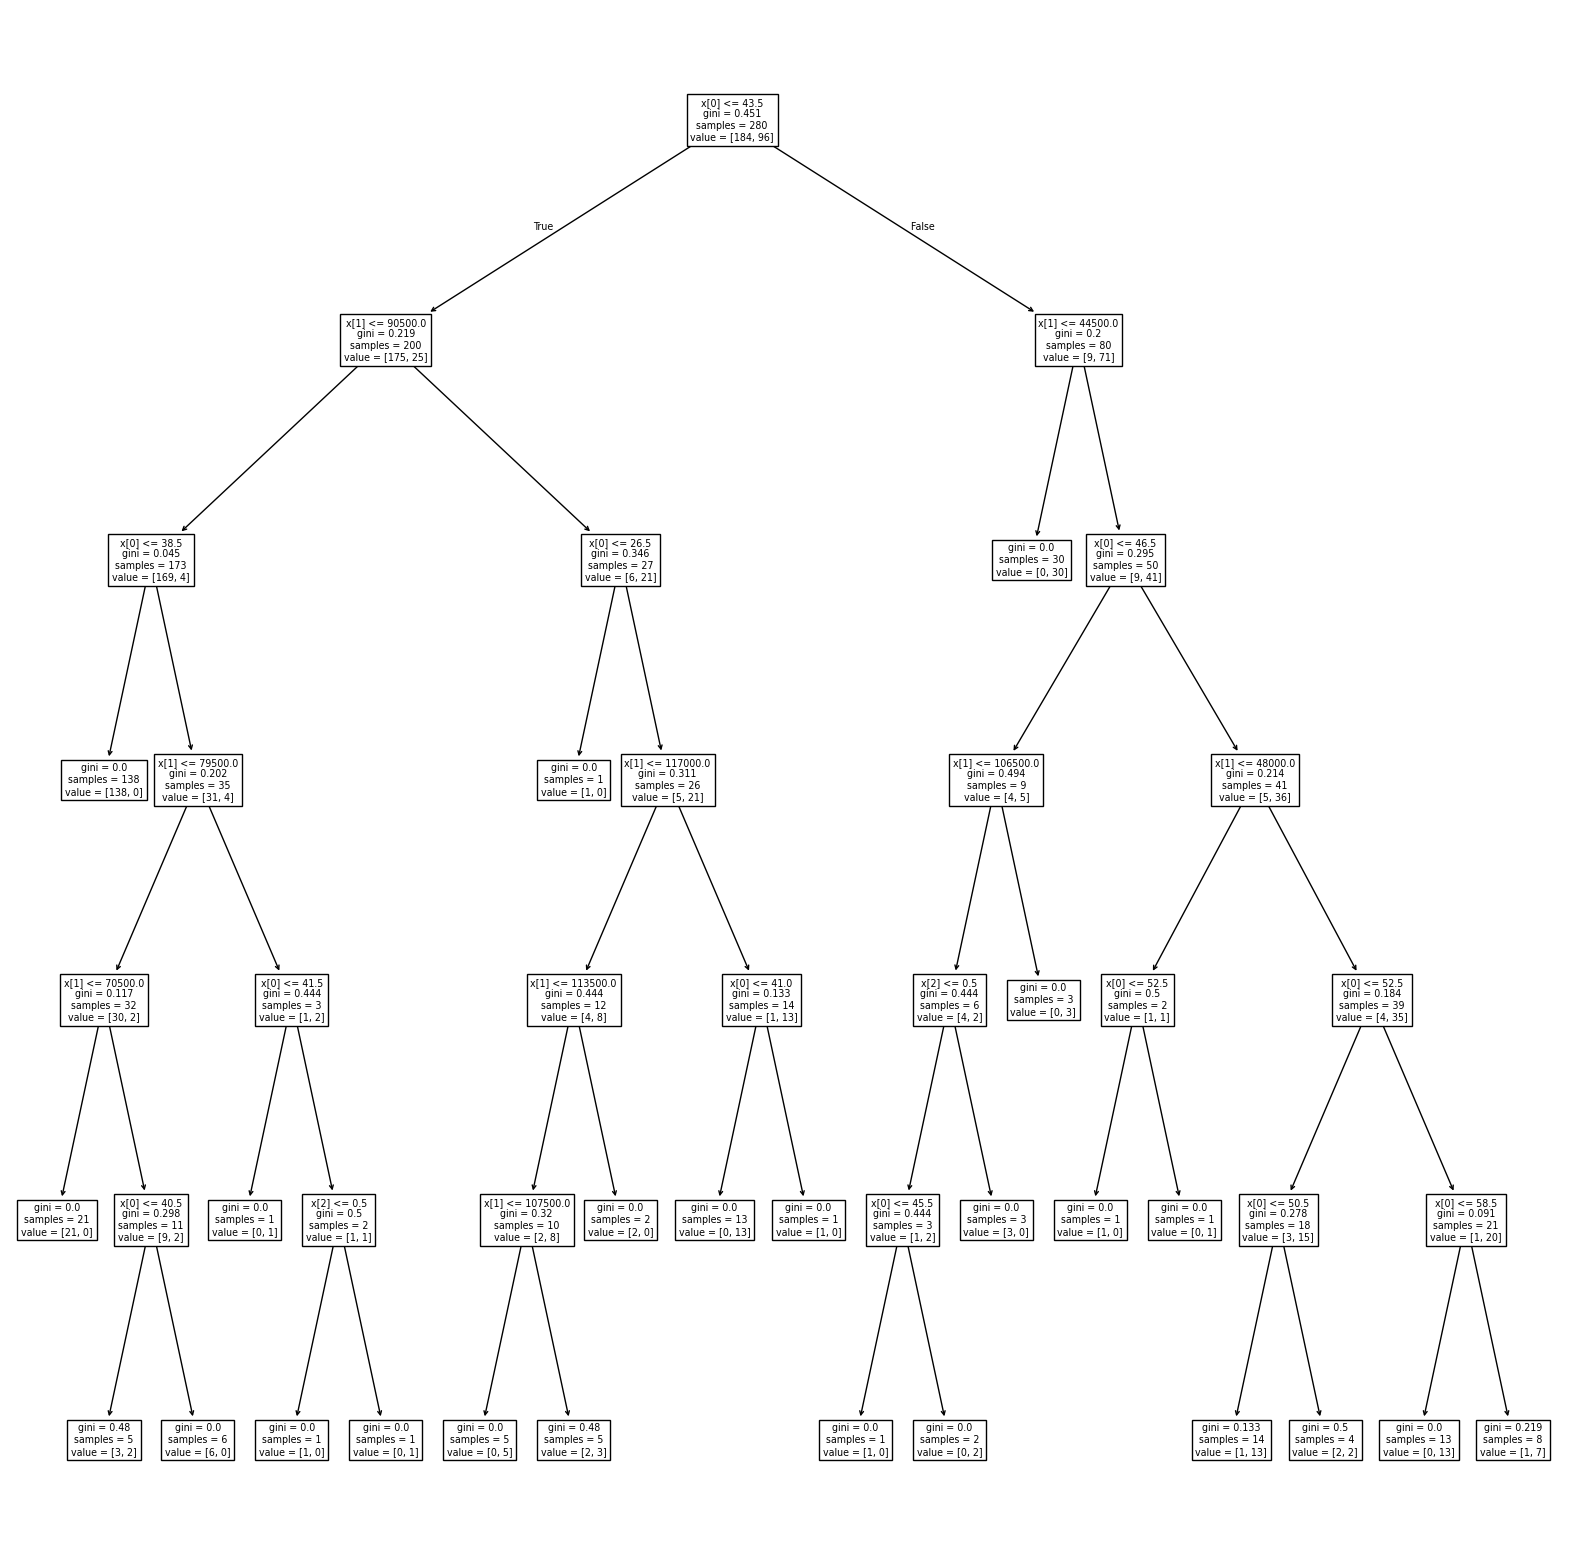

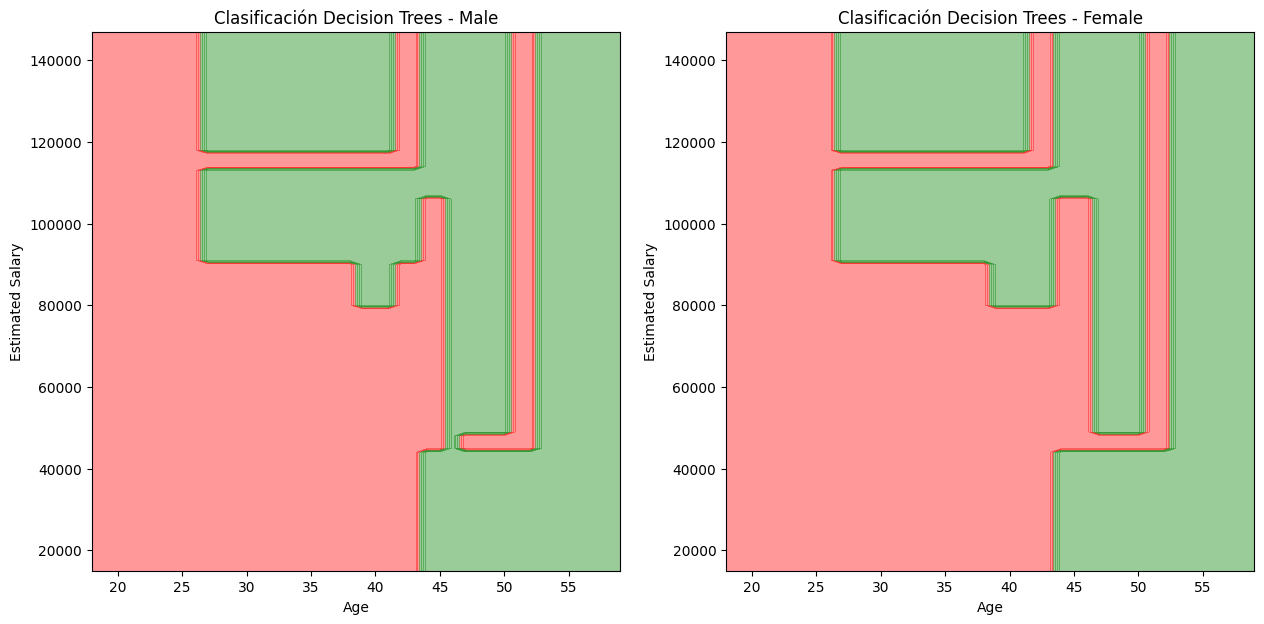

In [65]:
# seleccionamos las variables predictoras y la variable dependiente
X = df_a[['Age','EstimatedSalary','Gender']]
y = df_a['Purchased']

#datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)


#definimos el modelo y especificamos sus hiperparámetros
classifier = DecisionTreeClassifier(max_depth=6)

#ajustamos a los datos de entrenamiento
classifier.fit(X_train, y_train)


fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)
plot_tree(classifier, ax=ax)


#predecimos las categorías para el dataset de prueba
y_pred_test = classifier.predict(X_test)


fig = plt.figure(figsize=(15,7))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

#creamos una grilla con valores de X1 (Age) y X2 (EstimatedSalary)
X1, X2 = np.meshgrid(np.arange(X_train.Age.min(), X_train.Age.max(),1),
                     np.arange(X_train.EstimatedSalary.min(),X_train.EstimatedSalary.max(),1000))

X3_male = np.zeros(len(X1.ravel()))#male
X3_female = np.ones(len(X1.ravel()))#male

#male
X_grid = np.array([X1.ravel(), X2.ravel(),X3_male]).T  
mesh_predict = classifier.predict(X_grid).reshape(X1.shape)

im = ax1.contourf(X1, X2, mesh_predict, alpha = 0.4, cmap = ListedColormap(('red', 'green')))

#female
X_grid = np.array([X1.ravel(), X2.ravel(),X3_female]).T  
mesh_predict = classifier.predict(X_grid).reshape(X1.shape)
im = ax2.contourf(X1, X2, mesh_predict, alpha = 0.4, cmap = ListedColormap(('red', 'green')))


for ax in [ax1,ax2]:
    #ax.scatter(X_train.Age,X_train.EstimatedSalary,c=y_train,s=40,edgecolors='k',cmap=ListedColormap(('red', 'green')),label='Train')
    #ax.scatter(X_test.Age,X_test.EstimatedSalary,c=y_test,marker='s',s=40,edgecolors='k',cmap=ListedColormap(('red', 'green')),label='Test')

    ax.set_xlim(X1.min(), X1.max())
    ax.set_ylim(X2.min(), X2.max())
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    #ax.legend()
    
ax1.set_title('Clasificación Decision Trees - Male')
ax2.set_title('Clasificación Decision Trees - Female')





Confusion matrix: [[63 10]
 [10 37]]
Accuracy: 0.8333333333333334
Recall: 0.7872340425531915
Precision: 0.7872340425531915
F score: 0.7872340425531915
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        73
           1       0.79      0.79      0.79        47

    accuracy                           0.83       120
   macro avg       0.83      0.83      0.83       120
weighted avg       0.83      0.83      0.83       120



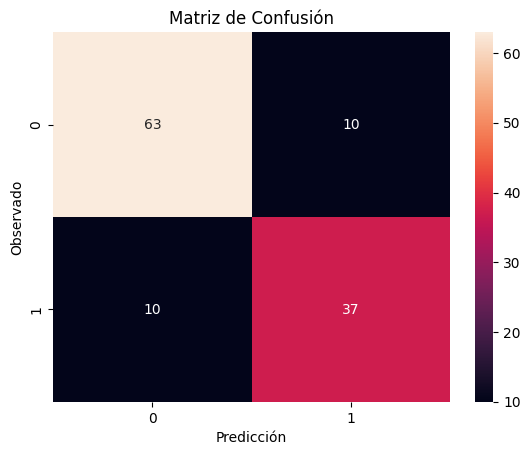

: 

In [ ]:
#matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred_test) #true,pred


print('Confusion matrix:',cm)

#graficamos la matriz de confusión
sns.heatmap(cm,annot=True)
plt.ylabel('Observado')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')

accuracy = metrics.accuracy_score(y_test,y_pred_test)
print('Accuracy:',accuracy) 

recall = metrics.recall_score(y_test,y_pred_test)
print('Recall:',recall) 

precision = metrics.precision_score(y_test,y_pred_test)
print('Precision:',precision) 

fscore = metrics.f1_score(y_test,y_pred_test)
print('F score:',fscore)

#también podemos imprimir un resumen de las métricas de clasificación
report0 = metrics.classification_report(y_test,y_pred_test)
print(report0)